In [36]:
from __future__ import annotations

import ast
import math
import sys
from pathlib import Path
from typing import Any, Literal

import pandas as pd


QAOA_CODE_DIR_CANDIDATES = [
    Path.cwd(),
    Path.cwd() / "Code",
    Path("/Users/julian/PycharmProjects/PythonProject/MasterThesis/QAOA/Code"),
    Path.home() / "MasterThesis/QAOA/Code",
]
QAOA_CODE_DIR = next((candidate for candidate in QAOA_CODE_DIR_CANDIDATES if (candidate / "Utils.py").exists()), None)
if QAOA_CODE_DIR is None:
    raise FileNotFoundError("Could not locate QAOA/Code/Utils.py for exact optimum lookup.")
if str(QAOA_CODE_DIR) not in sys.path:
    sys.path.insert(0, str(QAOA_CODE_DIR))

from Utils import get_exact_result_from_misc


AggregationMode = Literal["mean", "median", "best", "raw"]


RUN_SPECIFIC_COLUMNS = {
    "run_id",
    "duration_seconds",
    "finished_at",
    "processor",
    "hostname",
    "total_ram_gb",
    "physical_cores",
    "logical_cores",
    "python_version",
    "peak_ram_mb",
    "benchmark_repeat_idx",
    "sdp_seed",
    "sdp_seed.1",
    "lasserre_level",
    "initial_solver_level_M",
    "sdp_objective_value_step1",
    "sdp_objective_value_king_normalized_step1",
    "algorithm17_actual_energy",
    "algorithm17_lower_bound_energy",
    "initial_ws_energy_prodStates_step2",
    "initial_sdp_statevector_energy",
    "initial_qaoa_input_energy_normalized",
    "adam_energy_history_normalized_json",
    "adam_approx_ratio_history_json",
    "adam_updates_completed",
    "initial_sdp_statevec_ratio",
    "initial_ws_energy_010101",
    "QAOA_improvement_over_SDP_statevectorEnergy",
    "QAOA_improvement_over_SDP_prodStatesEnergy",
    "result",
    "result_010101",
    "approx_ratio",
    "approx_ratio_010101",
    "diff. approx. ratio",
    "sdp ws greater",
}

COMPARISON_SETTING_COLUMNS = [
    "p",
    "precision/iterations",
    "parameter_vector",
    "optimiser",
    "optimiser_use_heuristic",
    "heuristic_optimiser_iterations",
    "heuristic_optimiser_sampleSize",
    "circuit_type",
    "learning_rate_adam",
    "weighted",
    "graph_generation_type",
    "hog_graph_index",
    "result_name_suffix",
]


def _is_nan(x: Any) -> bool:
    try:
        return bool(pd.isna(x))
    except Exception:
        return False


def _safe_float(x: Any) -> float | None:
    if x is None or _is_nan(x):
        return None
    try:
        return float(x)
    except Exception:
        return None


# Explicit pre-rotation statevector columns can be added by the benchmark code later.
# Do NOT use initial_sdp_statevector_energy blindly for L2: with the current WarmStart.py,
# lasserre_level=2 returns the Algorithm-17 final statevector, so that column is post-rotation.
_PRE_ROTATION_STATEVECTOR_COLUMNS = (
    "pre_rotation_statevector_energy",
    "lasserre_gp_statevector_energy_pre_rotation",
    "initial_sdp_statevector_energy_pre_rotation",
)


def _row_lasserre_level(row: pd.Series) -> int | None:
    for key in ("lasserre_level", "lasserre_level_x", "lasserre_level_y"):
        value = row.get(key)
        if value is not None and not _is_nan(value):
            try:
                return int(value)
            except Exception:
                pass
    return None


def _pre_rotation_gp_energy(row: pd.Series) -> float | None:
    """
    Energy of the GP/GW warm-start state before Algorithm-17 rotations.

    For L1, initial_sdp_statevector_energy is a valid statevector evaluation because
    there is no Algorithm-17 rotation step. For L2, the current pipeline uses the
    Algorithm-17 final statevector as the warm start, so initial_sdp_statevector_energy
    is post-rotation and must not be used as a pre-rotation metric.

    If a future benchmark explicitly logs a pre-rotation statevector energy column,
    prefer that. Otherwise fall back to the product-state energy column, which is the
    available pre-rotation GP/GW energy.
    """
    for column in _PRE_ROTATION_STATEVECTOR_COLUMNS:
        if column in row.index:
            value = _safe_float(row.get(column))
            if value is not None:
                return value

    if _row_lasserre_level(row) == 1:
        value = _safe_float(row.get("initial_sdp_statevector_energy"))
        if value is not None:
            return value

    return _safe_float(row.get("initial_ws_energy_prodStates_step2"))


def _parse_literal(value: Any, default: Any = None) -> Any:
    if value is None or _is_nan(value):
        return default
    if not isinstance(value, str):
        return value

    value = value.strip()
    if not value:
        return default

    try:
        return ast.literal_eval(value)
    except Exception:
        return default


def _canonical_edges(edges_raw: Any) -> tuple[tuple[int, int], ...]:
    edges = _parse_literal(edges_raw, default=[])
    canonical = []

    for i, j in edges:
        i, j = int(i), int(j)
        canonical.append((min(i, j), max(i, j)))

    return tuple(sorted(canonical))


def _canonical_edge_weight_tuple(row: pd.Series) -> tuple[tuple[tuple[int, int], float], ...]:
    edges = _canonical_edges(row.get("edges"))
    weights_raw = row.get("weights")

    weights = _parse_literal(weights_raw, default=None)
    if weights is None:
        weights = [1.0] * len(edges)

    if len(weights) != len(edges):
        raise ValueError(
            f"weights length {len(weights)} does not match edges length {len(edges)} "
            f"for run_id={row.get('run_id')}"
        )

    edge_weights = [(edge, float(weight)) for edge, weight in zip(edges, weights)]
    return tuple(sorted(edge_weights, key=lambda x: x[0]))


def _edge_weight_dict(edge_weight_tuple: tuple[tuple[tuple[int, int], float], ...]) -> dict[tuple[int, int], float]:
    return {edge: weight for edge, weight in edge_weight_tuple}


def _normalise_key_value(value: Any) -> Any:
    if _is_nan(value):
        return None

    if isinstance(value, str):
        stripped = value.strip()
        parsed = _parse_literal(stripped, default=stripped)
        if isinstance(parsed, list):
            return tuple(parsed)
        if isinstance(parsed, dict):
            return tuple(sorted(parsed.items()))
        return parsed

    if isinstance(value, list):
        return tuple(value)

    if isinstance(value, dict):
        return tuple(sorted(value.items()))

    if isinstance(value, float) and value.is_integer():
        return int(value)

    return value


def _benchmark_key(row: pd.Series, extra_setting_columns: list[str] | None = None) -> tuple:
    graph_type = str(row.get("graph_generation_type", "unknown")).lower()
    n_vertices = int(row["n"])
    n_edges = int(row["m"])
    edge_weight_tuple = _canonical_edge_weight_tuple(row)

    default_setting_columns = [
        "p",
        "precision/iterations",
        "parameter_vector",
        "optimiser",
        "optimiser_use_heuristic",
        "heuristic_optimiser_iterations",
        "heuristic_optimiser_sampleSize",
        "circuit_type",
        "learning_rate_adam",
        "warm_start",
        "warm_start_mode",
        "singlet_injection",
        "start_index_singlet",
        "warm_start_corr_strength",
        "warm_start_corr_repeats",
        "compare_with_010101",
        "init_QAOAparams_close_to_zero",
        "use_correlations_as_initial_params",
        "weighted",
        "hog_graph_index",
    ]

    setting_columns = extra_setting_columns or default_setting_columns

    settings_tuple = tuple(
        (col, _normalise_key_value(row.get(col)))
        for col in setting_columns
        if col in row.index and col not in RUN_SPECIFIC_COLUMNS
    )

    return (
        graph_type,
        n_vertices,
        n_edges,
        edge_weight_tuple,
        settings_tuple,
    )


def _seed_key(row: pd.Series) -> tuple:
    """
    Key identifying one sampled repeat within a benchmark setting.
    Prefer sdp_seed. Fall back to benchmark_repeat_idx.
    """
    seed = _normalise_key_value(row.get("sdp_seed"))
    repeat_idx = _normalise_key_value(row.get("benchmark_repeat_idx"))

    if seed is not None:
        return ("sdp_seed", seed)

    if repeat_idx is not None:
        return ("benchmark_repeat_idx", repeat_idx)

    return ("anonymous_sample", None)


def _filter_to_common_seeds(
    g1: pd.DataFrame | None,
    g2: pd.DataFrame | None,
) -> tuple[pd.DataFrame | None, pd.DataFrame | None, list[tuple]]:
    if g1 is None and g2 is None:
        return None, None, []

    if g1 is None:
        g2 = g2.copy()
        g2["_sample_key"] = g2.apply(_seed_key, axis=1)
        sample_keys = sorted(set(g2["_sample_key"]), key=str)
        return None, g2, sample_keys

    if g2 is None:
        g1 = g1.copy()
        g1["_sample_key"] = g1.apply(_seed_key, axis=1)
        sample_keys = sorted(set(g1["_sample_key"]), key=str)
        return g1, None, sample_keys

    g1 = g1.copy()
    g2 = g2.copy()

    g1["_sample_key"] = g1.apply(_seed_key, axis=1)
    g2["_sample_key"] = g2.apply(_seed_key, axis=1)

    common_sample_keys = sorted(set(g1["_sample_key"]) & set(g2["_sample_key"]), key=str)

    g1_common = g1[g1["_sample_key"].isin(common_sample_keys)].copy()
    g2_common = g2[g2["_sample_key"].isin(common_sample_keys)].copy()

    return g1_common, g2_common, common_sample_keys


def _graph_instance_from_key(key: tuple) -> dict[str, Any]:
    graph_type, n_vertices, n_edges, edge_weight_tuple, settings_tuple = key
    settings = dict(settings_tuple)

    return {
        "graph_type": graph_type,
        "#vertices": n_vertices,
        "#edges": n_edges,
        "#qaoa_layers": settings.get("p"),
        "#adam_iterations": (
            settings.get("precision/iterations")
            if settings.get("precision/iterations") is not None
            else settings.get("iterations", settings.get("iterations_list"))
        ),
        "result_name_suffix": settings.get("result_name_suffix"),
        #"edge_weight_dict": _edge_weight_dict(edge_weight_tuple),
        ##"settings": settings,
    }


_EXACT_RESULT_MISC_CACHE: dict[tuple, float | None] = {}


def _exact_result_from_misc_for_row(row: pd.Series) -> float | None:
    edges = _parse_literal(row.get("edges"), default=None)
    if edges is None:
        return None

    weights = _parse_literal(row.get("weights"), default=None)
    n_value = _normalise_key_value(row.get("n"))
    m_value = _normalise_key_value(row.get("m"))

    if n_value is None or m_value is None:
        return None

    cache_key = (str(edges), str(weights), int(n_value), int(m_value))
    if cache_key not in _EXACT_RESULT_MISC_CACHE:
        _EXACT_RESULT_MISC_CACHE[cache_key] = get_exact_result_from_misc(
            edges,
            weights,
            int(n_value),
            int(m_value),
            raise_if_missing=False,
        )

    return _EXACT_RESULT_MISC_CACHE[cache_key]


def _optimal_value_from_row(row: pd.Series) -> float | None:
    optimal = _safe_float(row.get("optimal_result"))
    if optimal is not None:
        return optimal

    result = _safe_float(row.get("result"))
    approx = _safe_float(row.get("approx_ratio"))

    if result is not None and approx not in (None, 0.0):
        return result / approx

    return _exact_result_from_misc_for_row(row)


def _series_stats(values: list[float | None], mode: AggregationMode = "mean") -> dict[str, Any]:
    clean = [float(v) for v in values if v is not None and not math.isnan(float(v))]

    if not clean:
        return {
            "value": None,
            "min": None,
            "mean": None,
            "median": None,
            "max": None,
            "std": None,
            "count": 0,
            "raw": [],
        }

    s = pd.Series(clean, dtype=float)

    if mode == "mean":
        value = float(s.mean())
    elif mode == "median":
        value = float(s.median())
    elif mode == "best":
        value = float(s.max())
    elif mode == "raw":
        value = clean
    else:
        raise ValueError(f"Unknown aggregation mode: {mode}")

    return {
        "value": value,
        "min": float(s.min()),
        "mean": float(s.mean()),
        "median": float(s.median()),
        "max": float(s.max()),
        "std": float(s.std(ddof=1)) if len(clean) > 1 else 0.0,
        "count": int(len(clean)),
        "raw": clean,
    }


def _numeric_sequence(value: Any) -> list[float]:
    parsed = _parse_literal(value, default=None)
    if not isinstance(parsed, (list, tuple)):
        return []

    values = []
    for item in parsed:
        number = _safe_float(item)
        if number is not None:
            values.append(number)
    return values


def _adam_energy_history_from_row(row: pd.Series) -> list[float]:
    history = _numeric_sequence(row.get("adam_energy_history_normalized_json"))
    updates = _safe_float(row.get("adam_updates_completed"))
    if history and updates is not None and len(history) != int(updates) + 1:
        run_id = row.get("run_id", row.name)
        raise ValueError(
            f"Adam history for run {run_id!r} has {len(history)} entries, "
            f"but adam_updates_completed={int(updates)} requires {int(updates) + 1}."
        )
    return history


def _adam_trajectory_stats(
    rows: pd.DataFrame | None,
    *,
    as_approximation_ratio: bool,
    mode: AggregationMode,
) -> dict[int, dict[str, float | int | None]]:
    if rows is None or rows.empty:
        return {}

    values_by_update: dict[int, list[float]] = {}
    for _, row in rows.iterrows():
        energy_history = _adam_energy_history_from_row(row)
        ratio_history = _numeric_sequence(row.get("adam_approx_ratio_history_json"))

        if as_approximation_ratio and ratio_history:
            values = ratio_history
        elif as_approximation_ratio:
            optimal = _optimal_value_from_row(row)
            if optimal is None or optimal == 0:
                continue
            values = [energy / optimal for energy in energy_history]
        else:
            values = energy_history

        for update, value in enumerate(values):
            values_by_update.setdefault(update, []).append(value)

    return {
        update: _series_stats(values, mode=mode)
        for update, values in sorted(values_by_update.items())
    }


def _load_and_validate(path: str | Path, expected_lasserre_level: int) -> pd.DataFrame:
    df = pd.read_csv(path, skipinitialspace=True)

    if "lasserre_level" not in df.columns:
        raise ValueError(f"{path} has no lasserre_level column.")

    levels = set(pd.to_numeric(df["lasserre_level"], errors="coerce").dropna().astype(int))
    if expected_lasserre_level not in levels:
        raise ValueError(
            f"{path} does not contain lasserre_level={expected_lasserre_level}. "
            f"Found levels: {sorted(levels)}"
        )

    df = df[pd.to_numeric(df["lasserre_level"], errors="coerce").astype("Int64") == expected_lasserre_level].copy()
    return df


def _normalise_csv_paths(paths: Any) -> list[Path]:
    if paths is None:
        return []

    if isinstance(paths, (str, Path)):
        raw_paths = [paths]
    elif isinstance(paths, (list, tuple, set)):
        raw_paths = list(paths)
    else:
        raw_paths = [paths]

    resolved_paths = []
    for raw_path in raw_paths:
        if raw_path is None:
            continue
        if isinstance(raw_path, str) and not raw_path.strip():
            continue

        csv_path = Path(raw_path)
        if not csv_path.exists():
            print(f"Warning: configured CSV path does not exist, skipping: {csv_path}")
            continue

        resolved_paths.append(csv_path)

    return resolved_paths


def _path_is_present(path: Any) -> bool:
    return bool(_normalise_csv_paths(path))


def _iteration_values_from_cell(value: Any) -> list[float]:
    parsed = _parse_literal(value, default=value)
    if isinstance(parsed, (list, tuple, set)):
        raw_values = parsed
    else:
        raw_values = [parsed]

    values = []
    for raw in raw_values:
        if raw is None or _is_nan(raw):
            continue
        try:
            values.append(float(raw))
        except Exception:
            pass
    return values


def _normalise_iterations_filter(iterations_filter: Any) -> set[float] | None:
    if iterations_filter is None:
        return None

    values = _iteration_values_from_cell(iterations_filter)
    if not values:
        return None

    return set(values)


def _filter_by_adam_iterations(df: pd.DataFrame | None, iterations_filter: Any = None) -> pd.DataFrame | None:
    allowed_iterations = _normalise_iterations_filter(iterations_filter)
    if df is None or allowed_iterations is None:
        return df

    iteration_columns = [
        "precision/iterations",
        "iterations",
        "iterations_list",
    ]

    for column in iteration_columns:
        if column not in df.columns:
            continue

        mask = df[column].apply(
            lambda cell: any(value in allowed_iterations for value in _iteration_values_from_cell(cell))
        )
        return df[mask].copy()

    print("Warning: no iteration column found; ADAM_ITERATIONS_FILTER was not applied.")
    return df


def _load_optional_lasserre(paths: Any, expected_lasserre_level: int) -> pd.DataFrame | None:
    frames = [
        _load_and_validate(csv_path, expected_lasserre_level=expected_lasserre_level)
        for csv_path in _normalise_csv_paths(paths)
    ]

    if not frames:
        return None

    return pd.concat(frames, ignore_index=True, sort=False)


def _load_optional_qaoa_only(paths: Any) -> pd.DataFrame | None:
    frames = []

    for csv_path in _normalise_csv_paths(paths):
        df = pd.read_csv(csv_path, skipinitialspace=True)

        # Keep only actual QAOA-only / no-warm-start rows if those columns exist.
        if "warm_start" in df.columns:
            warm_start_bool = df["warm_start"].astype(str).str.lower().isin(["true", "1", "yes"])
            df = df[~warm_start_bool].copy()

        frames.append(df)

    if not frames:
        return None

    return pd.concat(frames, ignore_index=True, sort=False)


def _group_rows(df: pd.DataFrame, extra_setting_columns: list[str] | None = None) -> dict[tuple, pd.DataFrame]:
    grouped: dict[tuple, list[int]] = {}

    for idx, row in df.iterrows():
        key = _benchmark_key(row, extra_setting_columns=extra_setting_columns)
        grouped.setdefault(key, []).append(idx)

    return {key: df.loc[idxs].copy() for key, idxs in grouped.items()}


def aggregate_lasserre_qaoa_results(
    lasserre1_csv: Any,
    lasserre2_csv: Any,
    *,
    only_common: bool = True,
    only_common_samples: bool = True,
    aggregation_mode: AggregationMode = "mean",
    extra_setting_columns: list[str] | None = None,
    adam_iterations_filter: Any = None,
) -> dict[tuple, dict[str, Any]]:
    df1 = _load_optional_lasserre(lasserre1_csv, expected_lasserre_level=1)
    df2 = _load_optional_lasserre(lasserre2_csv, expected_lasserre_level=2)

    df1 = _filter_by_adam_iterations(df1, adam_iterations_filter)
    df2 = _filter_by_adam_iterations(df2, adam_iterations_filter)

    if ONLY_UNCLIPPED_WARM_START_QAOA:
        if df1 is not None and "result_before_warm_start_clip" in df1.columns:
            unclipped = (
                df1["result_before_warm_start_clip"].isna()
                | df1["result_before_warm_start_clip"].astype(str).str.strip().isin(["", "nan", "None"])
            )
            print(f"L1 unclipped rows kept: {unclipped.sum()}/{len(df1)}")
            df1 = df1[unclipped].copy()

        if df2 is not None and "result_before_warm_start_clip" in df2.columns:
            unclipped = (
                df2["result_before_warm_start_clip"].isna()
                | df2["result_before_warm_start_clip"].astype(str).str.strip().isin(["", "nan", "None"])
            )
            print(f"L2 unclipped rows kept: {unclipped.sum()}/{len(df2)}")
            df2 = df2[unclipped].copy()

    groups1 = {} if df1 is None else _group_rows(df1, extra_setting_columns=extra_setting_columns)
    groups2 = {} if df2 is None else _group_rows(df2, extra_setting_columns=extra_setting_columns)

    if not groups1 and not groups2:
        return {}

    if only_common and groups1 and groups2:
        keys = set(groups1) & set(groups2)
    else:
        keys = set(groups1) | set(groups2)

    keys = sorted(keys, key=str)

    aggregated: dict[tuple, dict[str, Any]] = {}

    for key in keys:
        g1_original = groups1.get(key)
        g2_original = groups2.get(key)

        if only_common_samples:
            g1, g2, common_sample_keys = _filter_to_common_seeds(g1_original, g2_original)

            if only_common and len(common_sample_keys) == 0:
                continue
        else:
            g1 = g1_original
            g2 = g2_original
            common_sample_keys = []

        n_l1_total = 0 if g1_original is None else len(g1_original)
        n_l2_total = 0 if g2_original is None else len(g2_original)

        n_l1_used = 0 if g1 is None else len(g1)
        n_l2_used = 0 if g2 is None else len(g2)
        n_common_samples = len(common_sample_keys) if only_common_samples else None

        optimal_candidates: list[float | None] = []
        if g1 is not None:
            optimal_candidates.extend(_optimal_value_from_row(row) for _, row in g1.iterrows())
        if g2 is not None:
            optimal_candidates.extend(_optimal_value_from_row(row) for _, row in g2.iterrows())

        graph_instance = _graph_instance_from_key(key)
        """graph_instance["samples"] = {
            "common_used": n_common_samples,
            "lasserre1_used": n_l1_used,
            "lasserre2_used": n_l2_used,
            "lasserre1_total_available": n_l1_total,
            "lasserre2_total_available": n_l2_total,
            #"sample_keys_used": common_sample_keys,
        }"""

        aggregated[key] = {
            "graph_instance": graph_instance,
            "optimal_value": _series_stats(optimal_candidates, mode=aggregation_mode),

            "lasserre1_value_step1": _series_stats(
                [] if g1 is None else [_safe_float(x) for x in g1["sdp_objective_value_step1"]],
                mode=aggregation_mode,
            ),
            "lasserre2_value_step1": _series_stats(
                [] if g2 is None else [_safe_float(x) for x in g2["sdp_objective_value_king_normalized_step1"]],
                mode=aggregation_mode,
            ),

            "lasserre1_value_after_gp_rounding_step2": _series_stats(
                [] if g1 is None else [_pre_rotation_gp_energy(row) for _, row in g1.iterrows()],
                mode=aggregation_mode,
            ),
            "lasserre2_value_after_gp_rounding_step2": _series_stats(
                [] if g2 is None else [_pre_rotation_gp_energy(row) for _, row in g2.iterrows()],
                mode=aggregation_mode,
            ),

            "lasserre2_value_after_rotations_step10": _series_stats(
                [] if g2 is None else [_safe_float(x) for x in g2["algorithm17_actual_energy"]],
                mode=aggregation_mode,
            ),
            "lasserre2_algorithm17_F_bound": _series_stats(
                [] if g2 is None else [_safe_float(x) for x in g2["algorithm17_lower_bound_energy"]],
                mode=aggregation_mode,
            ),

            "lasserre1_qaoa_result": _series_stats(
                [] if g1 is None else [_safe_float(x) for x in g1["result"]],
                mode=aggregation_mode,
            ),
            "lasserre2_qaoa_result": _series_stats(
                [] if g2 is None else [_safe_float(x) for x in g2["result"]],
                mode=aggregation_mode,
            ),
            "lasserre1_adam_energy_trajectory": _adam_trajectory_stats(
                g1, as_approximation_ratio=False, mode=aggregation_mode
            ),
            "lasserre2_adam_energy_trajectory": _adam_trajectory_stats(
                g2, as_approximation_ratio=False, mode=aggregation_mode
            ),
            "lasserre1_adam_ratio_trajectory": _adam_trajectory_stats(
                g1, as_approximation_ratio=True, mode=aggregation_mode
            ),
            "lasserre2_adam_ratio_trajectory": _adam_trajectory_stats(
                g2, as_approximation_ratio=True, mode=aggregation_mode
            ),

            "present_in_lasserre1": g1_original is not None,
            "present_in_lasserre2": g2_original is not None,

            "n_rows_lasserre1": n_l1_used,
            "n_rows_lasserre2": n_l2_used,
            "n_common_samples_used": n_common_samples,

            "n_rows_lasserre1_total_available": n_l1_total,
            "n_rows_lasserre2_total_available": n_l2_total,

            "common_sample_keys": common_sample_keys,
        }

    return aggregated


In [37]:
from pathlib import Path
from collections import defaultdict
import re

EXP5 = Path(
    "/Users/julian/PycharmProjects/PythonProject/MasterThesis/"
    "QAOA/Results/logs/ADAM/Exp6"
)

EXP5_NAME_ADDITION = "_Exp6_KingAmplifiedWithHeuristic_rerun2408"
EXP5_REQUIRED_FAMILIES = {"L2M2", "QAOA_only"}
ACTIVE_EXP5_SELECTION_TITLE = "EXP5 selection: not set"
ACTIVE_EXP5_SETTING = "*"
ACTIVE_EXP5_DATASET = "*"
ACTIVE_EXP5_NAME_ADDITION = EXP5_NAME_ADDITION
ACTIVE_EXP5_OUTPUT_DIR = EXP5 / EXP5_NAME_ADDITION.lstrip("_") / "_plots"


def _EXP5_selection_title(setting="*", dataset="*", name_addition=EXP5_NAME_ADDITION):
    setting_label = "all settings" if setting == "*" else setting
    dataset_label = "all datasets" if dataset == "*" else dataset
    name_label = "all name additions" if name_addition == "*" else name_addition
    return f"{setting_label} | {dataset_label} | {name_label}"


def _slugify_for_filename(value: str) -> str:
    slug = re.sub(r"[^A-Za-z0-9._=-]+", "_", str(value).strip())
    slug = re.sub(r"_+", "_", slug).strip("_")
    return slug or "selection"


def EXP5_active_title() -> str:
    only_unclipped = globals().get("ONLY_UNCLIPPED_WARM_START_QAOA", False)
    return f"{ACTIVE_EXP5_SELECTION_TITLE} | ONLY_UNCLIPPED_WARM_START_QAOA={only_unclipped}"


def EXP5_active_slug() -> str:
    return _slugify_for_filename(EXP5_active_title())


def EXP5_active_artifact_path(stem: str, suffix: str) -> Path:
    output_dir = globals().get("ACTIVE_EXP5_OUTPUT_DIR", EXP5 / EXP5_NAME_ADDITION.lstrip("_") / "_plots")
    output_dir.mkdir(parents=True, exist_ok=True)
    return output_dir / f"{stem}__{EXP5_active_slug()}{suffix}"


def EXP5_csvs(setting="*", dataset="*", name_addition=None):
    global ACTIVE_EXP5_SELECTION_TITLE, ACTIVE_EXP5_SETTING, ACTIVE_EXP5_DATASET
    global ACTIVE_EXP5_NAME_ADDITION, ACTIVE_EXP5_OUTPUT_DIR

    name_addition = EXP5_NAME_ADDITION if name_addition is None else name_addition
    ACTIVE_EXP5_SETTING = setting
    ACTIVE_EXP5_DATASET = dataset
    ACTIVE_EXP5_NAME_ADDITION = name_addition
    ACTIVE_EXP5_SELECTION_TITLE = _EXP5_selection_title(setting, dataset, name_addition)

    subexperiment_dir = EXP5 / name_addition.lstrip("_")
    setting_dir = "_all_settings" if setting == "*" else setting
    dataset_dir = "_all_datasets" if dataset == "*" else dataset
    ACTIVE_EXP5_OUTPUT_DIR = subexperiment_dir / setting_dir / dataset_dir / "figures"

    pattern_base = f"{setting}/{dataset}"

    def matching(family):
        return sorted(subexperiment_dir.glob(f"{pattern_base}/*_{family}_clipped.csv"))

    return matching("L1M1"), matching("L2M2"), matching("QAOA_only")


def _EXP5_family_from_name(name: str) -> str | None:
    if "_QAOA_only_clipped" in name:
        return "QAOA_only"
    if "_L1M1_clipped" in name:
        return "L1M1"
    if "_L2M1_clipped" in name:
        return "L2M1"
    if "_L2M2_clipped" in name:
        return "L2M2"
    return None


def EXP5_available_matrix(name_addition=None) -> dict[str, dict[str, set[str]]]:
    name_addition = EXP5_NAME_ADDITION if name_addition is None else name_addition
    subexperiment_dir = EXP5 / name_addition.lstrip("_")
    matrix: dict[str, dict[str, set[str]]] = defaultdict(lambda: defaultdict(set))
    for path in sorted(subexperiment_dir.glob("*/*/*_clipped.csv")):
        family = _EXP5_family_from_name(path.name)
        if family is None:
            continue
        setting = path.parents[1].name
        dataset = path.parent.name
        matrix[setting][dataset].add(family)
    return {setting: dict(datasets) for setting, datasets in matrix.items()}


def EXP5_complete_individual_selections(
    datasets: tuple[str, ...] = (
    "complete_2to12",
    "cycle_3to12",
    "path_2to12",
    "bipartite_454",
    "planar_clawfree_193",
    "regular_388",
),
    required: set[str] | None = None,
) -> list[tuple[str, str]]:
    required = EXP5_REQUIRED_FAMILIES if required is None else required
    matrix = EXP5_available_matrix()
    selections = []
    for setting in sorted(matrix):
        for dataset in datasets:
            families = matrix[setting].get(dataset, set())
            if required <= families:
                selections.append((setting, dataset))
    return selections


def EXP5_complete_setting_selections(
    required: set[str] | None = None,
) -> list[tuple[str, str]]:
    required = EXP5_REQUIRED_FAMILIES if required is None else required
    matrix = EXP5_available_matrix()
    selections = []
    for setting in sorted(matrix):
        if any(required <= families for families in matrix[setting].values()):
            selections.append((setting, "*"))
    return selections


def EXP5_complete_dataset_selections(
    required: set[str] | None = None,
) -> list[tuple[str, str]]:
    required = EXP5_REQUIRED_FAMILIES if required is None else required
    matrix = EXP5_available_matrix()
    datasets = {
        dataset
        for setting_datasets in matrix.values()
        for dataset, families in setting_datasets.items()
        if required <= families
    }
    return [("*", dataset) for dataset in sorted(datasets)]


def EXP5_refresh_batch_selections() -> list[tuple[str, str]]:
    global EXP5_INDIVIDUAL_SELECTIONS, EXP5_SETTING_SELECTIONS, EXP5_DATASET_SELECTIONS, EXP5_EVERYTHING_SELECTIONS, EXP5_BATCH_SELECTIONS
    EXP5_INDIVIDUAL_SELECTIONS = EXP5_complete_individual_selections()
    EXP5_SETTING_SELECTIONS = EXP5_complete_setting_selections()
    EXP5_DATASET_SELECTIONS = EXP5_complete_dataset_selections()
    EXP5_EVERYTHING_SELECTIONS = [("*", "*")]
    EXP5_BATCH_SELECTIONS = (
        EXP5_INDIVIDUAL_SELECTIONS
        + EXP5_SETTING_SELECTIONS
        + EXP5_DATASET_SELECTIONS
        + EXP5_EVERYTHING_SELECTIONS
    )
    return EXP5_BATCH_SELECTIONS


def print_EXP5_selection_options() -> None:
    EXP5_refresh_batch_selections()
    print("# 1. Individual dataset + setting")
    for setting, dataset in EXP5_INDIVIDUAL_SELECTIONS:
        print(f'# lasserre1_csv, lasserre2_csv, qaoa_only = EXP5_csvs("{setting}", "{dataset}")')
    print("\n# 2. Same setting, all datasets combined")
    for setting, _ in EXP5_SETTING_SELECTIONS:
        print(f'# lasserre1_csv, lasserre2_csv, qaoa_only = EXP5_csvs("{setting}")')
    print("\n# 3. Same graph dataset, all settings combined")
    for _, dataset in EXP5_DATASET_SELECTIONS:
        print(f'# lasserre1_csv, lasserre2_csv, qaoa_only = EXP5_csvs("*", "{dataset}")')
    print("\n# 4. Literally everything combined")
    print("# lasserre1_csv, lasserre2_csv, qaoa_only = EXP5_csvs()")


EXP5_refresh_batch_selections()

# Active single-selection default. Change this line when you want to inspect one setting manually.
lasserre1_csv, lasserre2_csv, qaoa_only = EXP5_csvs()


In [38]:
from pathlib import Path
import json
import math
import pandas as pd


# -----------------------------
# Input / output paths
# -----------------------------


ONLY_UNCLIPPED_WARM_START_QAOA = True

# One can also pass a list of Paths for any of these three inputs, for example:
# lasserre1_csv = [Path("/path/to/l1_run_a.csv"), Path("/path/to/l1_run_b.csv")]
# lasserre2_csv = [Path("/path/to/l2_run_a.csv"), Path("/path/to/l2_run_b.csv")]
# qaoa_only = [Path("/path/to/qaoa_only_a.csv"), Path("/path/to/qaoa_only_b.csv")]

output_csv = Path("aggregated_lasserre1_vs_lasserre2.csv")

# True keeps only settings present in both L1 and L2. False keeps the union of available L1/L2 settings.
# Use False when L1 and L2 jobs cover different graph/depth/iteration settings.
ONLY_COMMON_SETTINGS = True

# True: compare only matching repeat/seed rows. False: aggregate all rows per setting.
filter_common_seeds = True

# Raw per-run L1-vs-L2 difference diagnostics only make sense with matched seeds.
RUN_PAIRED_SEED_DIAGNOSTICS = filter_common_seeds

# Filters complete runs by their configured maximum Adam updates.
ADAM_ITERATIONS_FILTER = None

# Filters points from the stored trace without requiring separate reruns.
# For example: [0, 1, 2, 5, 10, 25, 50]. None keeps every stored update.
ADAM_TRAJECTORY_UPDATES_FILTER = None


# -----------------------------
# Compact cell helpers
# -----------------------------
def make_json_safe(obj):
    """
    Recursively convert Python objects into JSON-safe objects.
    In particular, tuple dict keys like (0, 1) become strings like "0-1".
    """
    if isinstance(obj, dict):
        safe = {}
        for k, v in obj.items():
            if isinstance(k, tuple):
                key = "-".join(map(str, k))
            else:
                key = str(k)
            safe[key] = make_json_safe(v)
        return safe

    if isinstance(obj, tuple):
        return [make_json_safe(x) for x in obj]

    if isinstance(obj, list):
        return [make_json_safe(x) for x in obj]

    if isinstance(obj, (pd.Series, pd.Index)):
        return [make_json_safe(x) for x in obj.tolist()]

    if pd.isna(obj) if not isinstance(obj, (list, tuple, dict)) else False:
        return None

    return obj


def json_cell(obj) -> str:
    return json.dumps(make_json_safe(obj), sort_keys=False)


def stats_cell(stats: dict, digits: int | None = 10) -> str:
    payload = {
        "min": stats.get("min"),
        "mean": stats.get("mean"),
        "median": stats.get("median"),
        "max": stats.get("max"),
        "std": stats.get("std"),
        "count": stats.get("count", 0),
    }

    if digits is not None:
        for key in ("min", "mean", "median", "max", "std"):
            if payload[key] is not None and not pd.isna(payload[key]):
                payload[key] = round(float(payload[key]), digits)

    return json_cell(payload)


def trajectory_stats_cell(
    trajectory: dict[int, dict[str, Any]],
    digits: int = 10,
) -> str:
    payload = {
        str(int(update)): json.loads(stats_cell(stats, digits=digits))
        for update, stats in sorted(trajectory.items())
    }
    return json_cell(payload)


def ratio_stats(metric_stats: dict, optimal_stats: dict) -> dict:
    metric_raw = metric_stats.get("raw", [])
    optimal_raw = optimal_stats.get("raw", [])

    metric_clean = [float(x) for x in metric_raw if x is not None and not math.isnan(float(x))]
    optimal_clean = [float(x) for x in optimal_raw if x is not None and not math.isnan(float(x)) and float(x) != 0.0]

    ratios = []
    if metric_clean:
        if len(optimal_clean) == 1:
            ratios = [m / optimal_clean[0] for m in metric_clean]
        elif len(optimal_clean) >= len(metric_clean):
            ratios = [m / optimal_clean[i] for i, m in enumerate(metric_clean)]
        elif metric_stats.get("mean") is not None and optimal_stats.get("mean") not in (None, 0.0):
            ratios = [float(metric_stats["mean"]) / float(optimal_stats["mean"])]

    return _series_stats(ratios)


def ratio_stats_cell(metric_stats: dict, optimal_stats: dict, digits: int | None = 10) -> str:
    return stats_cell(ratio_stats(metric_stats, optimal_stats), digits=digits)


def stats_value(stats: dict, key: str) -> float | None:
    value = stats.get(key)
    if value is None or pd.isna(value):
        return None
    return float(value)


def signed_stat_diff(left_stats: dict, right_stats: dict, key: str, digits: int | None = 10) -> float | None:
    left_value = stats_value(left_stats, key)
    right_value = stats_value(right_stats, key)
    if left_value is None or right_value is None:
        return None
    diff = left_value - right_value
    return round(diff, digits) if digits is not None else diff

# -----------------------------
# Aggregate over configured benchmark settings and sampled repeats/seeds
# -----------------------------
def build_lasserre_qaoa_comparison(
    lasserre1_csv,
    lasserre2_csv,
    qaoa_only,
    *,
    output_csv: Path = output_csv,
    save_code_csv: bool = True,
    save_results_csv: bool = True,
) -> pd.DataFrame:
    aggregated = aggregate_lasserre_qaoa_results(
        lasserre1_csv=lasserre1_csv,
        lasserre2_csv=lasserre2_csv,
        only_common=ONLY_COMMON_SETTINGS,
        only_common_samples=filter_common_seeds,
        aggregation_mode="mean",
        extra_setting_columns=COMPARISON_SETTING_COLUMNS,
        adam_iterations_filter=ADAM_ITERATIONS_FILTER,
    )

    qaoa_only_df = _load_optional_qaoa_only(qaoa_only)
    qaoa_only_df = _filter_by_adam_iterations(qaoa_only_df, ADAM_ITERATIONS_FILTER)

    qaoa_only_groups = {}
    if qaoa_only_df is not None:
        qaoa_only_groups = _group_rows(
            qaoa_only_df,
            extra_setting_columns=COMPARISON_SETTING_COLUMNS,
        )

    rows = []
    for benchmark_key, values in aggregated.items():
        graph_instance = values["graph_instance"]
        optimal_stats = values["optimal_value"]

        qaoa_only_group = qaoa_only_groups.get(benchmark_key)
        qaoa_only_result_stats = _series_stats(
            [] if qaoa_only_group is None else [_safe_float(x) for x in qaoa_only_group["result"]],
            mode="mean",
        )
        qaoa_only_energy_trajectory = _adam_trajectory_stats(
            qaoa_only_group, as_approximation_ratio=False, mode="mean"
        )
        qaoa_only_ratio_trajectory = _adam_trajectory_stats(
            qaoa_only_group, as_approximation_ratio=True, mode="mean"
        )

        qaoa_only_ratio_stats = ratio_stats(qaoa_only_result_stats, optimal_stats)
        l1_qaoa_ratio_stats = ratio_stats(values["lasserre1_qaoa_result"], optimal_stats)
        l2_qaoa_ratio_stats = ratio_stats(values["lasserre2_qaoa_result"], optimal_stats)

        rows.append({
            "graph_instance": json_cell(graph_instance),
            "sample_summary": json_cell({
                "common_used": values["n_common_samples_used"],
                "lasserre1_used": values["n_rows_lasserre1"],
                "lasserre2_used": values["n_rows_lasserre2"],
                "lasserre1_total_available": values["n_rows_lasserre1_total_available"],
                "lasserre2_total_available": values["n_rows_lasserre2_total_available"],
            }),
            "Optimal value from Vincenzo": stats_cell(values["optimal_value"]),
            "Lasserre 1 Step 1 energy from relaxation (before GW rounding)": stats_cell(values["lasserre1_value_step1"]),
            "Lasserre 2 Step 1 energy from relaxation (before GW rounding)": stats_cell(values["lasserre2_value_step1"]),
            "Lasserre 1 Step 2 pre-rotation GP/GW energy": stats_cell(values["lasserre1_value_after_gp_rounding_step2"]),
            "Lasserre 2 Step 2 pre-rotation GP/GW energy": stats_cell(values["lasserre2_value_after_gp_rounding_step2"]),
            "Lasserre 2 Algorithm 17 statevector energy after rotations": stats_cell(values["lasserre2_value_after_rotations_step10"]),
            "Lasserre 2 Algorithm 17 analytic F-bound": stats_cell(values["lasserre2_algorithm17_F_bound"]),
            "Lasserre 1 QAOA result after using SDP vector as warm start": stats_cell(values["lasserre1_qaoa_result"]),
            "Lasserre 2 QAOA result after using SDP vector as warm start": stats_cell(values["lasserre2_qaoa_result"]),
            "Lasserre 1 Step 1 SDP energy approx. ratio (before GW rounding)": ratio_stats_cell(values["lasserre1_value_step1"], optimal_stats),
            "Lasserre 2 Step 1 SDP energy approx. ratio (before GW rounding)": ratio_stats_cell(values["lasserre2_value_step1"], optimal_stats),
            "Lasserre 1 Step 2 pre-rotation GP/GW energy approx. ratio": ratio_stats_cell(values["lasserre1_value_after_gp_rounding_step2"], optimal_stats),
            "Lasserre 2 Step 2 pre-rotation GP/GW energy approx. ratio": ratio_stats_cell(values["lasserre2_value_after_gp_rounding_step2"], optimal_stats),
            "Lasserre 2 Algorithm 17 statevector approx. ratio after rotations": ratio_stats_cell(values["lasserre2_value_after_rotations_step10"], optimal_stats),
            "Lasserre 2 Algorithm 17 analytic F-bound approx. ratio": ratio_stats_cell(values["lasserre2_algorithm17_F_bound"], optimal_stats),
            "QAOA-only result without warm start": stats_cell(qaoa_only_result_stats),
                "Lasserre 1 Adam energy trajectory": trajectory_stats_cell(
                    values["lasserre1_adam_energy_trajectory"]
                ),
                "Lasserre 2 Adam energy trajectory": trajectory_stats_cell(
                    values["lasserre2_adam_energy_trajectory"]
                ),
                "QAOA-only Adam energy trajectory": trajectory_stats_cell(
                    qaoa_only_energy_trajectory
                ),
                "Lasserre 1 Adam approximation-ratio trajectory": trajectory_stats_cell(
                    values["lasserre1_adam_ratio_trajectory"]
                ),
                "Lasserre 2 Adam approximation-ratio trajectory": trajectory_stats_cell(
                    values["lasserre2_adam_ratio_trajectory"]
                ),
                "QAOA-only Adam approximation-ratio trajectory": trajectory_stats_cell(
                    qaoa_only_ratio_trajectory
                ),
            "QAOA-only approx. ratio without warm start": stats_cell(qaoa_only_ratio_stats),
            "Lasserre 1 QAOA approx. ratio": stats_cell(l1_qaoa_ratio_stats),
            "Lasserre 2 QAOA approx. ratio": stats_cell(l2_qaoa_ratio_stats),
            "L2 QAOA mean approx. ratio minus QAOA-only mean": signed_stat_diff(l2_qaoa_ratio_stats, qaoa_only_ratio_stats, "mean"),
            "L2 QAOA median approx. ratio minus QAOA-only median": signed_stat_diff(l2_qaoa_ratio_stats, qaoa_only_ratio_stats, "median"),
            "L1 QAOA mean approx. ratio minus QAOA-only mean": signed_stat_diff(l1_qaoa_ratio_stats, qaoa_only_ratio_stats, "mean"),
            "L1 QAOA median approx. ratio minus QAOA-only median": signed_stat_diff(l1_qaoa_ratio_stats, qaoa_only_ratio_stats, "median"),
            "L1 QAOA mean approx. ratio minus L2 QAOA mean": signed_stat_diff(l1_qaoa_ratio_stats, l2_qaoa_ratio_stats, "mean"),
            "L1 QAOA median approx. ratio minus L2 QAOA median": signed_stat_diff(l1_qaoa_ratio_stats, l2_qaoa_ratio_stats, "median"),
        })

    comparison_df = pd.DataFrame(rows)
    if comparison_df.empty:
        print("No legacy single-subexperiment comparison rows found; skipping CSV output.")
        return comparison_df

    def _sort_key(row):
        gi = json.loads(row["graph_instance"])
        return (
            gi.get("graph_type", ""),
            gi.get("#vertices", -1),
            gi.get("#edges", -1),
            gi.get("#qaoa_layers", -1),
            gi.get("#adam_iterations", -1),
            str(gi.get("settings", "")),
        )

    if not comparison_df.empty:
        comparison_df = (
            comparison_df
            .assign(_sort_key=comparison_df.apply(_sort_key, axis=1))
            .sort_values("_sort_key")
            .drop(columns="_sort_key")
            .reset_index(drop=True)
        )

    output_csv = Path(output_csv)
    if save_code_csv:
        comparison_df.to_csv(output_csv, index=False)
        print(f"Wrote {len(comparison_df)} benchmark settings to {output_csv}")

    if save_results_csv:
        active_results_csv = EXP5_active_artifact_path(output_csv.stem, output_csv.suffix)
        comparison_df.to_csv(active_results_csv, index=False)
        print(f"Saved active results CSV to {active_results_csv}")

    return comparison_df


comparison_df = build_lasserre_qaoa_comparison(
    lasserre1_csv=lasserre1_csv,
    lasserre2_csv=lasserre2_csv,
    qaoa_only=qaoa_only,
    output_csv=output_csv,
)

comparison_df.head()


L2 unclipped rows kept: 12974/14623
Wrote 12939 benchmark settings to aggregated_lasserre1_vs_lasserre2.csv
Saved active results CSV to /Users/julian/PycharmProjects/PythonProject/MasterThesis/QAOA/Results/logs/ADAM/Exp6/Exp6_KingAmplifiedWithHeuristic_rerun2408/_all_settings/_all_datasets/figures/aggregated_lasserre1_vs_lasserre2__all_settings_all_datasets_Exp6_KingAmplifiedWithHeuristic_rerun2408_ONLY_UNCLIPPED_WARM_START_QAOA=True.csv


,graph_instance,sample_summary,Optimal value from Vincenzo,Lasserre 1 Step 1 energy from relaxation (before GW rounding),Lasserre 2 Step 1 energy from relaxation (before GW rounding),Lasserre 1 Step 2 pre-rotation GP/GW energy,Lasserre 2 Step 2 pre-rotation GP/GW energy,Lasserre 2 Algorithm 17 statevector energy after rotations,Lasserre 2 Algorithm 17 analytic F-bound,Lasserre 1 QAOA result after using SDP vector as warm start,...,QAOA-only Adam approximation-ratio trajectory,QAOA-only approx. ratio without warm start,Lasserre 1 QAOA approx. ratio,Lasserre 2 QAOA approx. ratio,L2 QAOA mean approx. ratio minus QAOA-only mean,L2 QAOA median approx. ratio minus QAOA-only median,L1 QAOA mean approx. ratio minus QAOA-only mean,L1 QAOA median approx. ratio minus QAOA-only median,L1 QAOA mean approx. ratio minus L2 QAOA mean,L1 QAOA median approx. ratio minus L2 QAOA median
0,"{""graph_type"": ""hog"", ""#vertices"": 2, ""#edges""...","{""common_used"": 1, ""lasserre1_used"": 0, ""lasse...","{""min"": 1.0, ""mean"": 1.0, ""median"": 1.0, ""max""...","{""min"": null, ""mean"": null, ""median"": null, ""m...","{""min"": 0.9999999455, ""mean"": 0.9999999455, ""m...","{""min"": null, ""mean"": null, ""median"": null, ""m...","{""min"": 0.4999999827, ""mean"": 0.4999999891, ""m...","{""min"": 0.5940825633, ""mean"": 0.6411130242, ""m...","{""min"": 0.6241407957, ""mean"": 0.6241407957, ""m...","{""min"": null, ""mean"": null, ""median"": null, ""m...",...,"{""0"": {""min"": -0.0, ""mean"": 0.0847639075, ""med...","{""min"": 0.0, ""mean"": 0.4979116206, ""median"": 0...","{""min"": null, ""mean"": null, ""median"": null, ""m...","{""min"": 0.8723386435, ""mean"": 0.8778207807, ""m...",0.379909,0.379909,None,None,None,None
1,"{""graph_type"": ""hog"", ""#vertices"": 2, ""#edges""...","{""common_used"": 1, ""lasserre1_used"": 0, ""lasse...","{""min"": 1.0, ""mean"": 1.0, ""median"": 1.0, ""max""...","{""min"": null, ""mean"": null, ""median"": null, ""m...","{""min"": 0.9999999455, ""mean"": 0.9999999455, ""m...","{""min"": null, ""mean"": null, ""median"": null, ""m...","{""min"": 0.4999999827, ""mean"": 0.4999999891, ""m...","{""min"": 0.5940825633, ""mean"": 0.6411130242, ""m...","{""min"": 0.6241407957, ""mean"": 0.6241407957, ""m...","{""min"": null, ""mean"": null, ""median"": null, ""m...",...,"{""0"": {""min"": -0.0, ""mean"": -0.0, ""median"": -0...","{""min"": -0.0, ""mean"": -0.0, ""median"": -0.0, ""m...","{""min"": null, ""mean"": null, ""median"": null, ""m...","{""min"": 0.6758412373, ""mean"": 0.7647557359, ""m...",0.764756,0.764756,None,None,None,None
2,"{""graph_type"": ""hog"", ""#vertices"": 2, ""#edges""...","{""common_used"": 1, ""lasserre1_used"": 0, ""lasse...","{""min"": 1.0, ""mean"": 1.0, ""median"": 1.0, ""max""...","{""min"": null, ""mean"": null, ""median"": null, ""m...","{""min"": 0.9999999455, ""mean"": 0.9999999455, ""m...","{""min"": null, ""mean"": null, ""median"": null, ""m...","{""min"": 0.4999999827, ""mean"": 0.4999999891, ""m...","{""min"": 0.5940825633, ""mean"": 0.6411130242, ""m...","{""min"": 0.6241407957, ""mean"": 0.6241407957, ""m...","{""min"": null, ""mean"": null, ""median"": null, ""m...",...,"{""0"": {""min"": 0.3371788843, ""mean"": 0.36538929...","{""min"": 0.8231394799, ""mean"": 0.8841686858, ""m...","{""min"": null, ""mean"": null, ""median"": null, ""m...","{""min"": 0.6369408608, ""mean"": 0.7363434397, ""m...",-0.147825,-0.147825,None,None,None,None
3,"{""graph_type"": ""hog"", ""#vertices"": 2, ""#edges""...","{""common_used"": 1, ""lasserre1_used"": 0, ""lasse...","{""min"": 1.0, ""mean"": 1.0, ""median"": 1.0, ""max""...","{""min"": null, ""mean"": null, ""median"": null, ""m...","{""min"": 0.9999999455, ""mean"": 0.9999999455, ""m...","{""min"": null, ""mean"": null, ""median"": null, ""m...","{""min"": 0.4999999827, ""mean"": 0.4999999891, ""m...","{""min"": 0.5940825633, ""mean"": 0.6411130242, ""m...","{""min"": 0.6241407957, ""mean"": 0.6241407957, ""m...","{""min"": null,

In [39]:
import json
import pandas as pd

actual_col = "Lasserre 2 Algorithm 17 statevector approx. ratio after rotations"
qaoa_col = "Lasserre 2 QAOA approx. ratio"


def mean_from_json(cell):
    if pd.isna(cell) or not str(cell).strip():
        return pd.NA
    return json.loads(cell).get("mean", pd.NA)


if comparison_df.empty or not {actual_col, qaoa_col} <= set(comparison_df.columns):
    out = pd.DataFrame(columns=["actual_statevector", "qaoa"])
    print("Skipped legacy L2 summary because comparison_df is empty.")
else:
    out = pd.DataFrame({
        "actual_statevector": comparison_df[actual_col].apply(mean_from_json),
        "qaoa": comparison_df[qaoa_col].apply(mean_from_json),
    }).dropna()

    out["absolute_improvement"] = out["qaoa"] - out["actual_statevector"]
    out["relative_improvement_pct"] = 100 * out["absolute_improvement"] / out["actual_statevector"]

    print(f"Rows: {len(out)}")
    print(f"Improved: {(out['absolute_improvement'] > 0).sum()} / {len(out)}")
    print(f"Worse: {(out['absolute_improvement'] < 0).sum()} / {len(out)}")
    print()
    print(out[["absolute_improvement", "relative_improvement_pct"]].agg(["min", "mean", "median", "max"]))


Rows: 12884
Improved: 7701 / 12884
Worse: 0 / 12884

        absolute_improvement  relative_improvement_pct
min                 0.000000                  0.000000
mean                0.050386                  8.595845
median              0.021894                  3.334087
max                 0.539508                147.765283


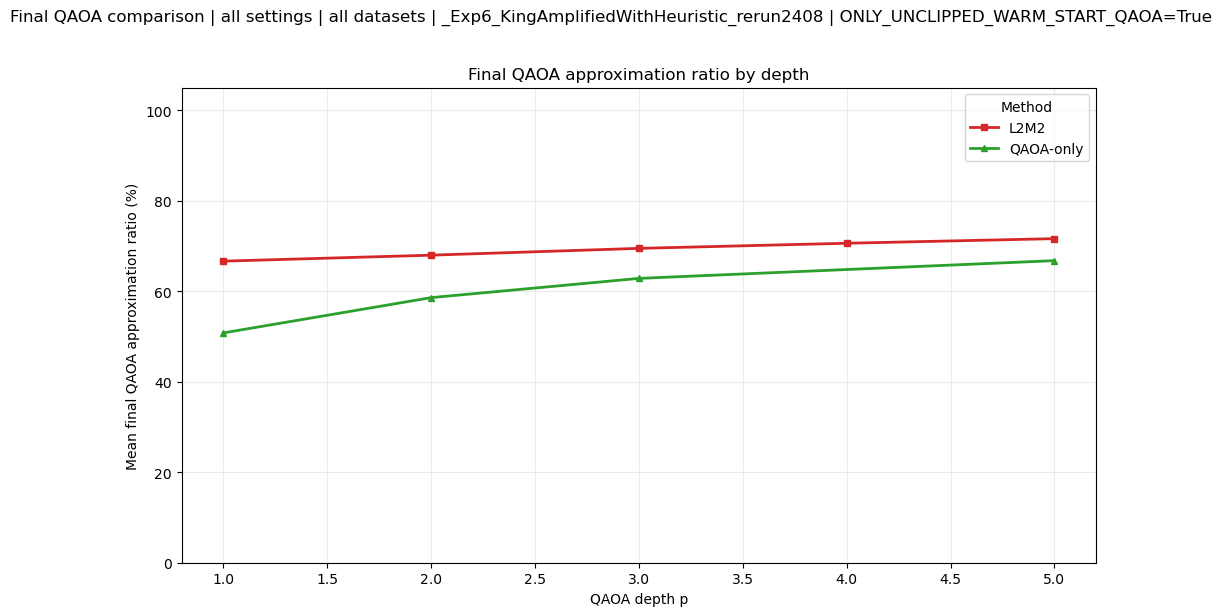

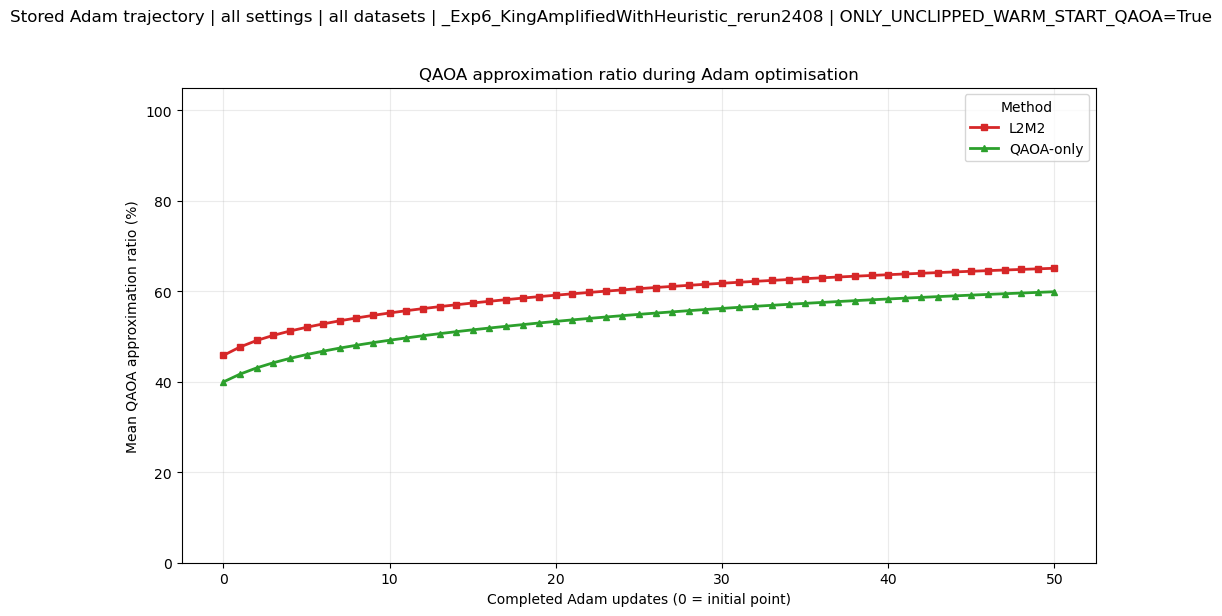

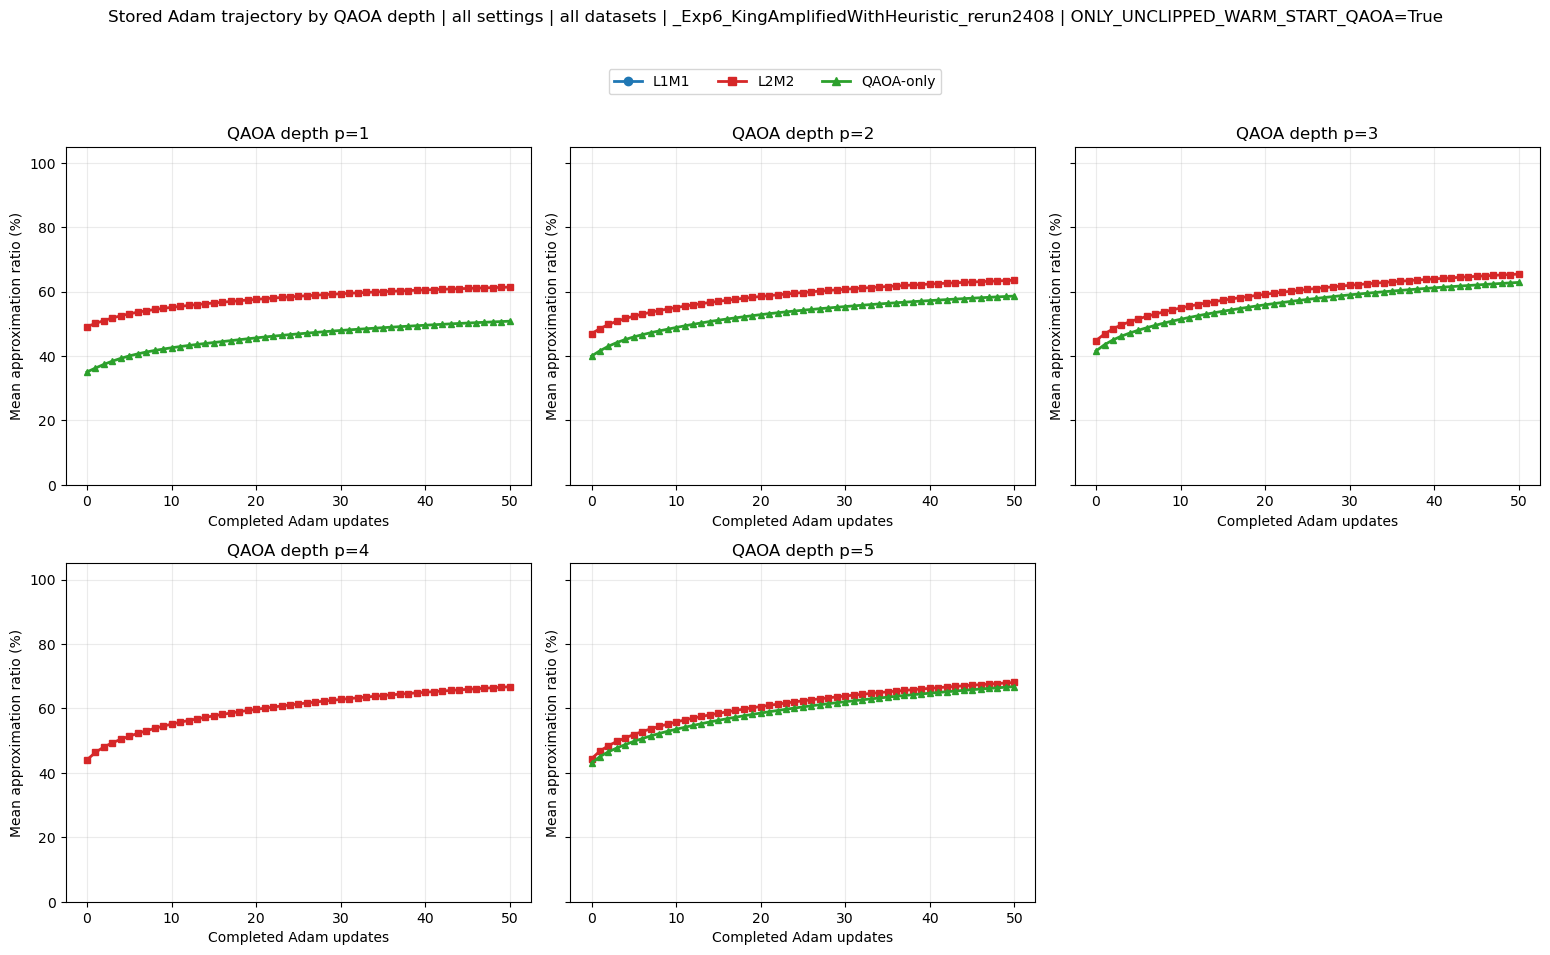

Selection: all settings | all datasets | _Exp6_KingAmplifiedWithHeuristic_rerun2408 | ONLY_UNCLIPPED_WARM_START_QAOA=True
Rows: 12884
Improved: 7701 / 12884
Worse: 0 / 12884

        absolute_improvement  relative_improvement_pct
min                 0.000000                  0.000000
mean                0.050386                  8.595845
median              0.021894                  3.334087
max                 0.539508                147.765283
Saved final-depth plot to /Users/julian/PycharmProjects/PythonProject/MasterThesis/QAOA/Results/logs/ADAM/Exp6/Exp6_KingAmplifiedWithHeuristic_rerun2408/_all_settings/_all_datasets/figures/final_qaoa_ratio_by_qaoa_depth__all_settings_all_datasets_Exp6_KingAmplifiedWithHeuristic_rerun2408_ONLY_UNCLIPPED_WARM_START_QAOA=True.png
Saved Adam-trajectory plot to /Users/julian/PycharmProjects/PythonProject/MasterThesis/QAOA/Results/logs/ADAM/Exp6/Exp6_KingAmplifiedWithHeuristic_rerun2408/_all_settings/_all_datasets/figures/qaoa_ratio_trajectory_by_ada

In [40]:
# -----------------------------
# Final-QAOA comparison and stored Adam-trajectory plots
# -----------------------------
import json
import math
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
from matplotlib.lines import Line2D


FINAL_QAOA_RATIO_COLUMNS = {
    "L1M1": "Lasserre 1 QAOA approx. ratio",
    "L2M2": "Lasserre 2 QAOA approx. ratio",
    "QAOA-only": "QAOA-only approx. ratio without warm start",
}

ADAM_RATIO_TRAJECTORY_COLUMNS = {
    "L1M1": "Lasserre 1 Adam approximation-ratio trajectory",
    "L2M2": "Lasserre 2 Adam approximation-ratio trajectory",
    "QAOA-only": "QAOA-only Adam approximation-ratio trajectory",
}

SDP_BASELINE_RATIO_COLUMNS = {
    "L1 SDP Result": "Lasserre 1 Step 2 pre-rotation GP/GW energy approx. ratio",
    "L2 SDP Result": "Lasserre 2 Algorithm 17 statevector approx. ratio after rotations",
}

METHOD_STYLE = {
    "L1M1": {"color": "#1f77b4", "marker": "o"},
    "L2M2": {"color": "#d62728", "marker": "s"},
    "QAOA-only": {"color": "#2ca02c", "marker": "^"},
}

SDP_BASELINE_STYLE = {
    "L1 SDP Result": {"color": "black", "linestyle": "-"},
    "L2 SDP Result": {"color": "black", "linestyle": ":"},
}

SDP_BASELINE_QAOA_METHOD = {
    "L1 SDP Result": "L1M1",
    "L2 SDP Result": "L2M2",
}


def parse_json_payload(cell) -> dict:
    if isinstance(cell, dict):
        return cell
    if cell is None or pd.isna(cell) or not str(cell).strip():
        return {}
    try:
        payload = json.loads(str(cell))
    except (TypeError, ValueError, json.JSONDecodeError):
        return {}
    return payload if isinstance(payload, dict) else {}


def numeric_or_none(value):
    value = pd.to_numeric(pd.Series([value]), errors="coerce").iloc[0]
    return None if pd.isna(value) else float(value)


def stats_mean(cell):
    return numeric_or_none(parse_json_payload(cell).get("mean"))


def stats_median(cell):
    return numeric_or_none(parse_json_payload(cell).get("median"))


def stats_count(cell):
    value = numeric_or_none(parse_json_payload(cell).get("count"))
    return 0 if value is None else int(value)


def qaoa_setting_value(row: pd.Series, column: str, graph_key: str):
    value = numeric_or_none(row.get(column))
    if value is not None:
        return value
    return numeric_or_none(parse_json_payload(row.get("graph_instance")).get(graph_key))


def aggregate_mean_ratio(frame: pd.DataFrame, group_columns: list[str]) -> pd.DataFrame:
    if frame.empty:
        return pd.DataFrame(columns=group_columns + ["mean_qaoa_approx_ratio", "median_qaoa_approx_ratio", "n_settings"])

    rows = []
    grouped = frame.groupby(group_columns, dropna=False, sort=True)
    for key, group in grouped:
        if not isinstance(key, tuple):
            key = (key,)
        row = dict(zip(group_columns, key))
        row.update(
            {
                "mean_qaoa_approx_ratio": float(group["mean_qaoa_approx_ratio"].mean()),
                "median_qaoa_approx_ratio": float(group["median_qaoa_approx_ratio"].median()),
                "n_settings": int(len(group)),
            }
        )
        rows.append(row)
    return pd.DataFrame(rows)


def qaoa_ratio_axis_upper(data: pd.DataFrame) -> float:
    if data.empty:
        return 1.0
    max_value = pd.to_numeric(data["mean_qaoa_approx_ratio"], errors="coerce").max()
    if pd.isna(max_value):
        return 1.0
    return max(1.0, math.ceil((float(max_value) + 0.02) / 0.05) * 0.05)


def plot_method_lines(ax, data: pd.DataFrame, x_column: str, title: str, y_max: float) -> None:
    for method in FINAL_QAOA_RATIO_COLUMNS:
        subset = data[data["method"] == method].sort_values(x_column)
        if subset.empty:
            continue
        style = METHOD_STYLE[method]
        ax.plot(
            subset[x_column],
            100.0 * subset["mean_qaoa_approx_ratio"],
            label=method,
            color=style["color"],
            marker=style["marker"],
            linewidth=2,
            markersize=5,
        )
    ax.set_title(title)
    ax.set_ylim(0, 100.0 * y_max)
    ax.grid(True, alpha=0.25)


def plot_sdp_baseline_lines(ax, baseline_data: pd.DataFrame, qaoa_data: pd.DataFrame) -> None:
    present_qaoa_methods = set(qaoa_data["method"]) if not qaoa_data.empty else set()
    for method in SDP_BASELINE_RATIO_COLUMNS:
        if SDP_BASELINE_QAOA_METHOD[method] not in present_qaoa_methods:
            continue
        subset = baseline_data[baseline_data["method"] == method]
        if subset.empty:
            continue
        style = SDP_BASELINE_STYLE[method]
        ax.axhline(
            100.0 * float(subset["mean_qaoa_approx_ratio"].mean()),
            label=method,
            color=style["color"],
            linestyle=style["linestyle"],
            linewidth=2,
        )


def selection_plot_title(prefix: str) -> str:
    return f"{prefix} | {EXP5_active_title()}"


def plot_output_path(stem: str, suffix: str) -> Path:
    return EXP5_active_artifact_path(stem, ".png")


def save_or_show(fig, path: Path, show: bool, save: bool) -> None:
    fig.tight_layout()
    if save:
        fig.savefig(path, dpi=200, bbox_inches="tight")
    if show:
        plt.show()
    else:
        plt.close(fig)


def build_final_plot_rows(frame: pd.DataFrame) -> pd.DataFrame:
    rows = []
    for _, row in frame.iterrows():
        depth = qaoa_setting_value(row, "QAOA layers", "#qaoa_layers")
        configured_updates = qaoa_setting_value(row, "#adam_iterations", "#adam_iterations")
        for method, column in FINAL_QAOA_RATIO_COLUMNS.items():
            mean_value = stats_mean(row.get(column))
            if mean_value is None:
                continue
            rows.append(
                {
                    "method": method,
                    "qaoa_layers": None if depth is None else int(depth),
                    "configured_adam_updates": None if configured_updates is None else int(configured_updates),
                    "mean_qaoa_approx_ratio": mean_value,
                    "median_qaoa_approx_ratio": stats_median(row.get(column)),
                    "count": stats_count(row.get(column)),
                }
            )
    return pd.DataFrame(rows)


def build_sdp_baseline_plot_rows(frame: pd.DataFrame) -> pd.DataFrame:
    rows = []
    for _, row in frame.iterrows():
        depth = qaoa_setting_value(row, "QAOA layers", "#qaoa_layers")
        for method, column in SDP_BASELINE_RATIO_COLUMNS.items():
            mean_value = stats_mean(row.get(column))
            if mean_value is None:
                continue
            rows.append(
                {
                    "method": method,
                    "qaoa_layers": None if depth is None else int(depth),
                    "mean_qaoa_approx_ratio": mean_value,
                }
            )
    return pd.DataFrame(rows, columns=["method", "qaoa_layers", "mean_qaoa_approx_ratio"])


def build_trajectory_plot_rows(frame: pd.DataFrame) -> pd.DataFrame:
    rows = []
    for _, row in frame.iterrows():
        depth = qaoa_setting_value(row, "QAOA layers", "#qaoa_layers")
        for method, column in ADAM_RATIO_TRAJECTORY_COLUMNS.items():
            for update, stats in parse_json_payload(row.get(column)).items():
                update_number = numeric_or_none(update)
                mean_value = numeric_or_none(stats.get("mean")) if isinstance(stats, dict) else None
                if update_number is None or mean_value is None:
                    continue
                rows.append(
                    {
                        "method": method,
                        "qaoa_layers": None if depth is None else int(depth),
                        "adam_update": int(update_number),
                        "mean_qaoa_approx_ratio": mean_value,
                        "median_qaoa_approx_ratio": numeric_or_none(stats.get("median")),
                        "count": int(numeric_or_none(stats.get("count")) or 0),
                    }
                )

    result = pd.DataFrame(rows)
    requested_updates = _normalise_iterations_filter(ADAM_TRAJECTORY_UPDATES_FILTER)
    if not result.empty and requested_updates is not None:
        result = result[result["adam_update"].isin({int(value) for value in requested_updates})].copy()
    return result


def save_l2_qaoa_vs_actual_statevector_summary(frame: pd.DataFrame) -> Path:
    actual_column = "Lasserre 2 Algorithm 17 statevector approx. ratio after rotations"
    qaoa_column = "Lasserre 2 QAOA approx. ratio"
    rows = []
    for _, row in frame.iterrows():
        actual = stats_mean(row.get(actual_column))
        qaoa = stats_mean(row.get(qaoa_column))
        if actual is not None and qaoa is not None:
            rows.append({"actual_statevector": actual, "qaoa": qaoa})

    data = pd.DataFrame(rows)
    lines = [f"Selection: {EXP5_active_title()}", f"Rows: {len(data)}"]
    if not data.empty:
        data["absolute_improvement"] = data["qaoa"] - data["actual_statevector"]
        data["relative_improvement_pct"] = (
            100 * data["absolute_improvement"] / data["actual_statevector"]
        )
        lines.extend([
            f"Improved: {(data['absolute_improvement'] > 0).sum()} / {len(data)}",
            f"Worse: {(data['absolute_improvement'] < 0).sum()} / {len(data)}",
            "",
            data[["absolute_improvement", "relative_improvement_pct"]]
                .agg(["min", "mean", "median", "max"])
                .to_string(),
        ])

    text = "\n".join(lines)
    path = EXP5_active_artifact_path("l2_qaoa_vs_actual_statevector_summary", ".txt")
    path.write_text(text + "\n", encoding="utf-8")
    print(text)
    return path


def plot_final_qaoa_ratio_comparison(
    frame: pd.DataFrame,
    *,
    output_csv: Path = output_csv,
    show: bool = True,
    save: bool = True,
) -> dict[str, object]:
    if frame.empty:
        raise ValueError("comparison_df is empty; rerun the aggregation cell and check the active filters.")

    final_plot_df = build_final_plot_rows(frame)
    if final_plot_df.empty:
        raise ValueError(
            "No final QAOA approximation-ratio values found in comparison_df. "
            "Rerun the aggregation cell and check the active filters."
        )

    selection_suffix = EXP5_active_slug()
    y_max = qaoa_ratio_axis_upper(final_plot_df)
    depth_summary = aggregate_mean_ratio(final_plot_df.dropna(subset=["qaoa_layers"]), ["qaoa_layers", "method"])

    fig, ax = plt.subplots(figsize=(10, 6))
    plot_method_lines(ax, depth_summary, "qaoa_layers", "Final QAOA approximation ratio by depth", y_max)
    ax.set_xlabel("QAOA depth p")
    ax.set_ylabel("Mean final QAOA approximation ratio (%)")
    ax.legend(title="Method")
    fig.suptitle(selection_plot_title("Final QAOA comparison"), y=1.02)
    final_depth_plot_path = plot_output_path("final_qaoa_ratio_by_qaoa_depth", selection_suffix)
    save_or_show(fig, final_depth_plot_path, show, save)

    trajectory_plot_df = build_trajectory_plot_rows(frame)
    sdp_baseline_plot_df = build_sdp_baseline_plot_rows(frame)
    trajectory_plot_path = None
    trajectory_overall_plot_path = None

    if trajectory_plot_df.empty:
        print(
            "No stored Adam trajectories found. The selected CSVs may predate "
            "adam_energy_history_normalized_json; the final-depth plot was still saved."
        )
    else:
        present_qaoa_methods = set(trajectory_plot_df["method"])
        visible_baseline_methods = {
            method
            for method, qaoa_method in SDP_BASELINE_QAOA_METHOD.items()
            if qaoa_method in present_qaoa_methods
        }
        visible_sdp_baseline_df = sdp_baseline_plot_df[
            sdp_baseline_plot_df["method"].isin(visible_baseline_methods)
        ].copy()
        trajectory_axis_data = pd.concat(
            [trajectory_plot_df, visible_sdp_baseline_df], ignore_index=True, sort=False
        )
        trajectory_y_max = qaoa_ratio_axis_upper(trajectory_axis_data)
        trajectory_summary = aggregate_mean_ratio(trajectory_plot_df, ["adam_update", "method"])

        fig, ax = plt.subplots(figsize=(10, 6))
        plot_method_lines(ax, trajectory_summary, "adam_update", "QAOA approximation ratio during Adam optimisation", trajectory_y_max)
        plot_sdp_baseline_lines(ax, visible_sdp_baseline_df, trajectory_plot_df)
        ax.set_xlabel("Completed Adam updates (0 = initial point)")
        ax.set_ylabel("Mean QAOA approximation ratio (%)")
        ax.legend(title="Method")
        fig.suptitle(selection_plot_title("Stored Adam trajectory"), y=1.02)
        trajectory_overall_plot_path = plot_output_path("qaoa_ratio_trajectory_by_adam_update", selection_suffix)
        save_or_show(fig, trajectory_overall_plot_path, show, save)

        depths = sorted(int(value) for value in trajectory_plot_df["qaoa_layers"].dropna().unique())
        if depths:
            ncols = min(3, len(depths))
            nrows = math.ceil(len(depths) / ncols)
            fig, axes = plt.subplots(nrows, ncols, figsize=(5.2 * ncols, 4.4 * nrows), squeeze=False, sharey=True)
            flat_axes = list(axes.flat)

            for ax, depth in zip(flat_axes, depths):
                depth_data = trajectory_plot_df[trajectory_plot_df["qaoa_layers"] == depth]
                depth_baseline_data = visible_sdp_baseline_df[visible_sdp_baseline_df["qaoa_layers"] == depth]
                depth_summary = aggregate_mean_ratio(depth_data, ["adam_update", "method"])
                plot_method_lines(ax, depth_summary, "adam_update", f"QAOA depth p={depth}", trajectory_y_max)
                plot_sdp_baseline_lines(ax, depth_baseline_data, depth_data)
                ax.set_xlabel("Completed Adam updates")
                ax.set_ylabel("Mean approximation ratio (%)")

            for ax in flat_axes[len(depths):]:
                ax.set_visible(False)

            legend_handles = [
                Line2D(
                    [0],
                    [0],
                    color=METHOD_STYLE[method]["color"],
                    marker=METHOD_STYLE[method]["marker"],
                    linewidth=2,
                    label=method,
                )
                for method in FINAL_QAOA_RATIO_COLUMNS
            ]
            legend_handles.extend(
                Line2D(
                    [0],
                    [0],
                    color=SDP_BASELINE_STYLE[method]["color"],
                    linestyle=SDP_BASELINE_STYLE[method]["linestyle"],
                    linewidth=2,
                    label=method,
                )
                for method in SDP_BASELINE_RATIO_COLUMNS
                if method in visible_baseline_methods
                and not visible_sdp_baseline_df[visible_sdp_baseline_df["method"] == method].empty
            )
            fig.legend(handles=legend_handles, loc="upper center", ncol=len(legend_handles), bbox_to_anchor=(0.5, 1.02))
            fig.suptitle(selection_plot_title("Stored Adam trajectory by QAOA depth"), y=1.08)
            trajectory_plot_path = plot_output_path("qaoa_ratio_trajectory_by_adam_update_and_depth", selection_suffix)
            save_or_show(fig, trajectory_plot_path, show, save)

    summary_path = save_l2_qaoa_vs_actual_statevector_summary(frame) if save else None
    last_plot_path = trajectory_plot_path or trajectory_overall_plot_path or final_depth_plot_path

    if save:
        print(f"Saved final-depth plot to {final_depth_plot_path}")
        if trajectory_overall_plot_path is not None:
            print(f"Saved Adam-trajectory plot to {trajectory_overall_plot_path}")
        if trajectory_plot_path is not None:
            print(f"Saved per-depth Adam-trajectory plot to {trajectory_plot_path}")
        print(f"Saved L2M2 improvement summary to {summary_path}")

    return {
        "qaoa_plot_df": final_plot_df,
        "trajectory_plot_df": trajectory_plot_df,
        "final_depth_plot_path": final_depth_plot_path,
        "trajectory_overall_plot_path": trajectory_overall_plot_path,
        "trajectory_plot_path": trajectory_plot_path,
        "last_plot_path": last_plot_path,
        "summary_path": summary_path,
    }


if comparison_df.empty:
    print("Skipped legacy single-subexperiment plots because comparison_df is empty.")
    plot_result = {}
    qaoa_plot_df = pd.DataFrame()
    adam_trajectory_plot_df = pd.DataFrame()
else:
    plot_result = plot_final_qaoa_ratio_comparison(
        comparison_df,
        output_csv=output_csv,
        show=True,
        save=True,
    )
    qaoa_plot_df = plot_result["qaoa_plot_df"]
    adam_trajectory_plot_df = plot_result["trajectory_plot_df"]


In [41]:
# -----------------------------
# EXP5 batch generation
# -----------------------------
# Generates all selected EXP5 CSV/plot/summary artifacts in sequence. 
# It runs each selection once with ONLY_UNCLIPPED_WARM_START_QAOA=True and once with False.

import pandas as pd


def run_EXP5_analysis_sequence(
    selections: list[tuple[str, str]] | None = None,
    *,
    filter_values: tuple[bool, ...] = (True, False),
    show_plots: bool = False,
    stop_on_error: bool = False,
) -> pd.DataFrame:
    global ONLY_UNCLIPPED_WARM_START_QAOA
    global lasserre1_csv, lasserre2_csv, qaoa_only, comparison_df, qaoa_plot_df, adam_trajectory_plot_df, plot_result

    if selections is None:
        selections = EXP5_refresh_batch_selections()

    log_rows = []
    for setting, dataset in selections:
        for only_unclipped in filter_values:
            ONLY_UNCLIPPED_WARM_START_QAOA = only_unclipped
            lasserre1_csv, lasserre2_csv, qaoa_only = EXP5_csvs(setting, dataset)
            print(f"\n=== {EXP5_active_title()} ===")
            print(f"L1 files: {len(lasserre1_csv)}, L2 files: {len(lasserre2_csv)}, QAOA-only files: {len(qaoa_only)}")

            try:
                comparison_df = build_lasserre_qaoa_comparison(
                    lasserre1_csv=lasserre1_csv,
                    lasserre2_csv=lasserre2_csv,
                    qaoa_only=qaoa_only,
                    output_csv=output_csv,
                    save_code_csv=True,
                    save_results_csv=True,
                )
                plot_result = plot_final_qaoa_ratio_comparison(
                    comparison_df,
                    output_csv=output_csv,
                    show=show_plots,
                    save=True,
                )
                qaoa_plot_df = plot_result["qaoa_plot_df"]
                adam_trajectory_plot_df = plot_result["trajectory_plot_df"]

                log_rows.append({
                    "setting": setting,
                    "dataset": dataset,
                    "ONLY_UNCLIPPED_WARM_START_QAOA": only_unclipped,
                    "status": "ok",
                    "rows": len(comparison_df),
                    "plot_path": str(plot_result["last_plot_path"]),
                        "final_depth_plot": str(plot_result["final_depth_plot_path"]),
                        "trajectory_plot": (
                            None
                            if plot_result["trajectory_plot_path"] is None
                            else str(plot_result["trajectory_plot_path"])
                        ),
                    "summary_path": str(plot_result["summary_path"]),
                    "output_dir": str(globals().get("ACTIVE_EXP5_OUTPUT_DIR")),
                })
            except Exception as exc:
                log_rows.append({
                    "setting": setting,
                    "dataset": dataset,
                    "ONLY_UNCLIPPED_WARM_START_QAOA": only_unclipped,
                    "status": "failed",
                    "error": repr(exc),
                    "output_dir": str(globals().get("ACTIVE_EXP5_OUTPUT_DIR")),
                })
                print(f"FAILED: {exc!r}")
                if stop_on_error:
                    raise

    batch_log_df = pd.DataFrame(log_rows)
    batch_log_path = EXP5 / "_batch_logs" / f"EXP5_batch_generation__{pd.Timestamp.now().strftime('%Y%m%d_%H%M%S')}.csv"
    batch_log_path.parent.mkdir(parents=True, exist_ok=True)
    batch_log_df.to_csv(batch_log_path, index=False)
    print(f"\nSaved batch log to {batch_log_path}")
    return batch_log_df


# Run everything in sequence:
EXP5_batch_log_df = run_EXP5_analysis_sequence()

# Run only the individual dataset/settings:
# EXP5_batch_log_df = run_EXP5_analysis_sequence(EXP5_INDIVIDUAL_SELECTIONS)

# Run only the all-settings aggregates for each graph dataset:
# EXP5_batch_log_df = run_EXP5_analysis_sequence(EXP5_DATASET_SELECTIONS)

# Show the currently discovered options:
# print_EXP5_selection_options()



=== lr001_noheuristic | complete_2to12 | _Exp6_KingAmplifiedWithHeuristic_rerun2408 | ONLY_UNCLIPPED_WARM_START_QAOA=True ===
L1 files: 0, L2 files: 1, QAOA-only files: 1
L2 unclipped rows kept: 13/45
Wrote 13 benchmark settings to aggregated_lasserre1_vs_lasserre2.csv
Saved active results CSV to /Users/julian/PycharmProjects/PythonProject/MasterThesis/QAOA/Results/logs/ADAM/Exp6/Exp6_KingAmplifiedWithHeuristic_rerun2408/lr001_noheuristic/complete_2to12/figures/aggregated_lasserre1_vs_lasserre2__lr001_noheuristic_complete_2to12_Exp6_KingAmplifiedWithHeuristic_rerun2408_ONLY_UNCLIPPED_WARM_START_QAOA=True.csv
Selection: lr001_noheuristic | complete_2to12 | _Exp6_KingAmplifiedWithHeuristic_rerun2408 | ONLY_UNCLIPPED_WARM_START_QAOA=True
Rows: 13
Improved: 10 / 13
Worse: 0 / 13

        absolute_improvement  relative_improvement_pct
min                 0.000000                  0.000000
mean                0.041823                  6.150289
median              0.039502                  5

In [42]:
# -----------------------------
# Occurrence analysis: when L2 pre-rotation rounding is worse than L1
# -----------------------------
# This cell checks raw paired runs before aggregation.
# Pairing is by the same benchmark key and the same sampled repeat/seed.
#
# Interpretation:
# - pre_rotation_gp_energy is the GP/GW warm-start energy before Algorithm-17 rotations.
# - For L1, this can be the statevector energy because there is no Algorithm-17 step.
# - For L2, initial_sdp_statevector_energy is not used as pre-rotation unless an explicit
#   pre-rotation statevector column exists; with the current WarmStart.py it is post-rotation.
# - algorithm17_actual_energy remains the explicit L2 post-rotation statevector energy.
# - sdp_relaxation_objective is the raw SDP relaxation upper bound.
#   For the SDP relaxation row, lower is tighter, so L2 - L1 < 0 is good.

from pathlib import Path
import numpy as np
import pandas as pd


def _pct_l2_worse(l1, l2):
    """
    Percentage by which L2 is worse than L1 for larger-is-better energy metrics.
    Returns 0.0 if L2 is not worse.
    """
    if l1 is None or l2 is None:
        return np.nan

    l1 = _safe_float(l1)
    l2 = _safe_float(l2)

    if l1 is None or l2 is None or pd.isna(l1) or pd.isna(l2) or abs(l1) < 1e-12:
        return np.nan

    return 100.0 * max(0.0, float(l1) - float(l2)) / abs(float(l1))


def _first_existing_float(row, columns):
    for col in columns:
        if col in row.index:
            value = _safe_float(row.get(col))
            if value is not None and not pd.isna(value):
                return value
    return None


def _sdp_relaxation_objective(row):
    return _first_existing_float(row, [
        "sdp_objective_value_step1",
        "sdp_objective_value",
        "initial_sdp_objective_value",
        "SDP objective value",
    ])


PAIRED_RUN_COLUMNS = [
    "graph_type",
    "n_vertices",
    "n_edges",
    "sample_key",
    "l1_sdp_relaxation_objective",
    "l2_sdp_relaxation_objective",
    "l2_sdp_minus_l1_sdp",
    "l1_pre_rotation_gp_energy",
    "l2_pre_rotation_gp_energy",
    "l2_algorithm17_statevector_energy",
    "l2_algorithm17_F_bound",
    "l1_qaoa_result",
    "l2_qaoa_result",
    "l2_pre_minus_l1_pre",
    "l2_alg17_statevec_minus_l1_pre",
    "l2_alg17_statevec_minus_l2_pre",
    "l2_F_bound_minus_l1_pre",
    "l2_qaoa_minus_l1_qaoa",
    "pct_l2_pre_worse_than_l1_pre",
    "pct_l2_alg17_statevec_worse_than_l1_pre",
    "pct_l2_F_bound_worse_than_l1_pre",
    "pct_l2_qaoa_worse_than_l1_qaoa",
]


def _paired_l1_l2_rows(
    lasserre1_csv: Any = lasserre1_csv,
    lasserre2_csv: Any = lasserre2_csv,
    *,
    extra_setting_columns: list[str] | None = COMPARISON_SETTING_COLUMNS,
    adam_iterations_filter: Any = ADAM_ITERATIONS_FILTER,
    only_unclipped: bool = False
) -> pd.DataFrame:
    if not RUN_PAIRED_SEED_DIAGNOSTICS:
        print("Skipping paired L1-vs-L2 diagnostics because filter_common_seeds=False.")
        return pd.DataFrame(columns=PAIRED_RUN_COLUMNS)

    if lasserre1_csv is None or lasserre2_csv is None:
        print("Skipping paired L1-vs-L2 diagnostics because one Lasserre CSV path is None.")
        return pd.DataFrame(columns=PAIRED_RUN_COLUMNS)

    df1 = _load_optional_lasserre(lasserre1_csv, expected_lasserre_level=1)
    df2 = _load_optional_lasserre(lasserre2_csv, expected_lasserre_level=2)

    df1 = _filter_by_adam_iterations(df1, adam_iterations_filter)
    df2 = _filter_by_adam_iterations(df2, adam_iterations_filter)

    if only_unclipped:
        if df1 is not None and "result_before_warm_start_clip" in df1.columns:
            unclipped = (
                df1["result_before_warm_start_clip"].isna()
                | df1["result_before_warm_start_clip"].astype(str).str.strip().isin(["", "nan", "None"])
            )
            print(f"L1 unclipped rows kept: {unclipped.sum()}/{len(df1)}")
            df1 = df1[unclipped].copy()

        if df2 is not None and "result_before_warm_start_clip" in df2.columns:
            unclipped = (
                df2["result_before_warm_start_clip"].isna()
                | df2["result_before_warm_start_clip"].astype(str).str.strip().isin(["", "nan", "None"])
            )
            print(f"L2 unclipped rows kept: {unclipped.sum()}/{len(df2)}")
            df2 = df2[unclipped].copy()

    if df1 is None or df2 is None:
        print("Skipping paired L1-vs-L2 diagnostics because one Lasserre CSV path is missing.")
        return pd.DataFrame(columns=PAIRED_RUN_COLUMNS)

    groups1 = _group_rows(df1, extra_setting_columns=extra_setting_columns)
    groups2 = _group_rows(df2, extra_setting_columns=extra_setting_columns)

    rows = []

    for key in sorted(set(groups1) & set(groups2), key=str):
        g1, g2, common_sample_keys = _filter_to_common_seeds(groups1[key], groups2[key])
        if g1 is None or g2 is None or not common_sample_keys:
            continue

        g1 = g1.copy()
        g2 = g2.copy()

        # If duplicated rows exist for the same sample key, keep the best QAOA result,
        # but keep the corresponding SDP/rounding columns from that same row.
        g1["_qaoa_result_numeric"] = pd.to_numeric(g1.get("result"), errors="coerce")
        g2["_qaoa_result_numeric"] = pd.to_numeric(g2.get("result"), errors="coerce")

        g1 = (
            g1.sort_values("_qaoa_result_numeric", ascending=False, na_position="last")
              .drop_duplicates("_sample_key", keep="first")
              .set_index("_sample_key")
        )
        g2 = (
            g2.sort_values("_qaoa_result_numeric", ascending=False, na_position="last")
              .drop_duplicates("_sample_key", keep="first")
              .set_index("_sample_key")
        )

        graph_info = _graph_instance_from_key(key)

        def _single_row_by_index_label(df: pd.DataFrame, label):
            rows = df.loc[[label]]

            if len(rows) > 1:
                print(f"Warning: duplicate sample key encountered; using first row: {label}")

            return rows.iloc[0]

        for sample_key in sorted(set(g1.index) & set(g2.index), key=str):
            r1 = _single_row_by_index_label(g1, sample_key)
            r2 = _single_row_by_index_label(g2, sample_key)

            l1_pre = _pre_rotation_gp_energy(r1)
            l2_pre = _pre_rotation_gp_energy(r2)

            l2_alg17_statevec = _safe_float(r2.get("algorithm17_actual_energy"))
            l2_alg17_f_bound = _safe_float(r2.get("algorithm17_lower_bound_energy"))

            l1_qaoa = _safe_float(r1.get("result"))
            l2_qaoa = _safe_float(r2.get("result"))

            l1_sdp = _sdp_relaxation_objective(r1)
            l2_sdp = _sdp_relaxation_objective(r2)

            rows.append({
                "graph_type": graph_info.get("graph_type"),
                "n_vertices": graph_info.get("#vertices"),
                "n_edges": graph_info.get("#edges"),
                "sample_key": str(sample_key),

                "l1_sdp_relaxation_objective": l1_sdp,
                "l2_sdp_relaxation_objective": l2_sdp,
                "l2_sdp_minus_l1_sdp": None if l1_sdp is None or l2_sdp is None else l2_sdp - l1_sdp,

                "l1_pre_rotation_gp_energy": l1_pre,
                "l2_pre_rotation_gp_energy": l2_pre,
                "l2_algorithm17_statevector_energy": l2_alg17_statevec,
                "l2_algorithm17_F_bound": l2_alg17_f_bound,
                "l1_qaoa_result": l1_qaoa,
                "l2_qaoa_result": l2_qaoa,

                "l2_pre_minus_l1_pre": None if l1_pre is None or l2_pre is None else l2_pre - l1_pre,
                "l2_alg17_statevec_minus_l1_pre": None if l1_pre is None or l2_alg17_statevec is None else l2_alg17_statevec - l1_pre,
                "l2_alg17_statevec_minus_l2_pre": None if l2_pre is None or l2_alg17_statevec is None else l2_alg17_statevec - l2_pre,
                "l2_F_bound_minus_l1_pre": None if l1_pre is None or l2_alg17_f_bound is None else l2_alg17_f_bound - l1_pre,
                "l2_qaoa_minus_l1_qaoa": None if l1_qaoa is None or l2_qaoa is None else l2_qaoa - l1_qaoa,

                "pct_l2_pre_worse_than_l1_pre": _pct_l2_worse(l1_pre, l2_pre),
                "pct_l2_alg17_statevec_worse_than_l1_pre": _pct_l2_worse(l1_pre, l2_alg17_statevec),
                "pct_l2_F_bound_worse_than_l1_pre": _pct_l2_worse(l1_pre, l2_alg17_f_bound),
                "pct_l2_qaoa_worse_than_l1_qaoa": _pct_l2_worse(l1_qaoa, l2_qaoa),
            })

    return pd.DataFrame(rows, columns=PAIRED_RUN_COLUMNS)


paired_runs_df = _paired_l1_l2_rows(only_unclipped=ONLY_UNCLIPPED_WARM_START_QAOA)

checks = {
    "L2 pre-rotation GP/GW worse than L1 pre-rotation GP/GW": (
        "l2_pre_minus_l1_pre",
        "pct_l2_pre_worse_than_l1_pre",
    ),
    "L2 Algorithm-17 statevector worse than L1 pre-rotation GP/GW": (
        "l2_alg17_statevec_minus_l1_pre",
        "pct_l2_alg17_statevec_worse_than_l1_pre",
    ),
    "L2 Algorithm-17 statevector worse than L2 pre-rotation GP/GW": (
        "l2_alg17_statevec_minus_l2_pre",
        None,
    ),
    "L2 Algorithm-17 F-bound worse than L1 pre-rotation GP/GW": (
        "l2_F_bound_minus_l1_pre",
        "pct_l2_F_bound_worse_than_l1_pre",
    ),
    "L2 QAOA result worse than L1 QAOA result": (
        "l2_qaoa_minus_l1_qaoa",
        "pct_l2_qaoa_worse_than_l1_qaoa",
    ),
}

summary_rows = []
by_graph_rows = []

# -----------------------------
# SDP relaxation comparison
# -----------------------------
# For this row only:
# - L2 - L1 < 0 means L2 is tighter.
# - No percentage columns are computed.
sdp_valid = paired_runs_df[
    pd.to_numeric(paired_runs_df["l2_sdp_minus_l1_sdp"], errors="coerce").notna()
].copy()

if sdp_valid.empty:
    summary_rows.append({
        "check": "L2 SDP relaxation upper bound tighter than L1 SDP relaxation upper bound",
        "n_valid_pairs": 0,
        "n_l2_worse": None,
        "frequency_l2_worse": None,
        "n_l2_tighter": 0,
        "frequency_l2_tighter": None,
        "mean_difference": None,
        "median_difference": None,
        "mean_pct_l2_worse": None,
        "median_pct_l2_worse": None,
        "max_pct_l2_worse": None,
    })
else:
    sdp_diffs = pd.to_numeric(sdp_valid["l2_sdp_minus_l1_sdp"], errors="coerce")
    sdp_l2_worse = sdp_diffs > 0
    sdp_l2_tighter = sdp_diffs < 0

    summary_rows.append({
        "check": "L2 SDP relaxation upper bound tighter than L1 SDP relaxation upper bound",
        "n_valid_pairs": int(len(sdp_valid)),
        "n_l2_worse": int(sdp_l2_worse.sum()),
        "frequency_l2_worse": float(sdp_l2_worse.mean()),
        "n_l2_tighter": int(sdp_l2_tighter.sum()),
        "frequency_l2_tighter": float(sdp_l2_tighter.mean()),
        "mean_difference": float(sdp_diffs.mean()),
        "median_difference": float(sdp_diffs.median()),
        "mean_pct_l2_worse": None,
        "median_pct_l2_worse": None,
        "max_pct_l2_worse": None,
    })

    grouped = (
        sdp_valid
        .assign(_diff=sdp_diffs, _worse=sdp_l2_worse, _tighter=sdp_l2_tighter)
        .groupby("graph_type", dropna=False)
    )

    for graph_type, g in grouped:
        by_graph_rows.append({
            "check": "L2 SDP relaxation upper bound tighter than L1 SDP relaxation upper bound",
            "graph_type": graph_type,
            "n_valid_pairs": int(len(g)),
            "n_l2_worse": int(g["_worse"].sum()),
            "frequency_l2_worse": float(g["_worse"].mean()),
            "n_l2_tighter": int(g["_tighter"].sum()),
            "frequency_l2_tighter": float(g["_tighter"].mean()),
            "mean_difference": float(g["_diff"].mean()),
            "median_difference": float(g["_diff"].median()),
            "mean_pct_l2_worse": None,
            "median_pct_l2_worse": None,
            "max_pct_l2_worse": None,
        })


# -----------------------------
# Rounded / QAOA energy comparisons
# -----------------------------
# For these rows:
# - L2 - L1 < 0 means L2 is worse.
# - Percentage columns measure by how much L2 falls below L1.
for label, (diff_col, pct_col) in checks.items():
    valid = paired_runs_df[pd.to_numeric(paired_runs_df[diff_col], errors="coerce").notna()].copy()

    if valid.empty:
        summary_rows.append({
            "check": label,
            "n_valid_pairs": 0,
            "n_l2_worse": 0,
            "frequency_l2_worse": None,
            "n_l2_tighter": None,
            "frequency_l2_tighter": None,
            "mean_difference": None,
            "median_difference": None,
            "mean_pct_l2_worse": None,
            "median_pct_l2_worse": None,
            "max_pct_l2_worse": None,
        })
        continue

    diffs = pd.to_numeric(valid[diff_col], errors="coerce")
    worse = diffs < 0

    if pct_col is not None:
        pct_values = pd.to_numeric(valid[pct_col], errors="coerce")
        pct_values_when_worse = pct_values[worse]
    else:
        pct_values = pd.Series(np.nan, index=valid.index)
        pct_values_when_worse = pd.Series(dtype=float)

    summary_rows.append({
        "check": label,
        "n_valid_pairs": int(len(valid)),
        "n_l2_worse": int(worse.sum()),
        "frequency_l2_worse": float(worse.mean()),
        "n_l2_tighter": None,
        "frequency_l2_tighter": None,
        "mean_difference": float(diffs.mean()),
        "median_difference": float(diffs.median()),

        # Percentage over all pairs: includes 0 when L2 is not worse.
        "mean_pct_l2_worse_all_pairs": None if pct_col is None else float(pct_values.mean()),
        "median_pct_l2_worse_all_pairs": None if pct_col is None else float(pct_values.median()),

        # Percentage only among cases where L2 is actually worse.
        "mean_pct_l1_better_when_l2_worse": None if pct_col is None or pct_values_when_worse.empty else float(pct_values_when_worse.mean()),
        "median_pct_l1_better_when_l2_worse": None if pct_col is None or pct_values_when_worse.empty else float(pct_values_when_worse.median()),
        "max_pct_l1_better_when_l2_worse": None if pct_col is None or pct_values_when_worse.empty else float(pct_values_when_worse.max()),
    })

    grouped = (
        valid
        .assign(_diff=diffs, _worse=worse, _pct_worse=pct_values)
        .groupby("graph_type", dropna=False)
    )

    for graph_type, g in grouped:
        if pct_col is not None:
            g_pct_when_worse = g.loc[g["_worse"], "_pct_worse"].dropna()
        else:
            g_pct_when_worse = pd.Series(dtype=float)

        by_graph_rows.append({
            "check": label,
            "graph_type": graph_type,
            "n_valid_pairs": int(len(g)),
            "n_l2_worse": int(g["_worse"].sum()),
            "frequency_l2_worse": float(g["_worse"].mean()),
            "n_l2_tighter": None,
            "frequency_l2_tighter": None,
            "mean_difference": float(g["_diff"].mean()),
            "median_difference": float(g["_diff"].median()),

            "mean_pct_l2_worse_all_pairs": None if pct_col is None else float(g["_pct_worse"].mean()),
            "median_pct_l2_worse_all_pairs": None if pct_col is None else float(g["_pct_worse"].median()),

            "mean_pct_l1_better_when_l2_worse": None if pct_col is None or g_pct_when_worse.empty else float(g_pct_when_worse.mean()),
            "median_pct_l1_better_when_l2_worse": None if pct_col is None or g_pct_when_worse.empty else float(g_pct_when_worse.median()),
            "max_pct_l1_better_when_l2_worse": None if pct_col is None or g_pct_when_worse.empty else float(g_pct_when_worse.max()),
        })

occurrence_summary_df = pd.DataFrame(summary_rows)
occurrence_by_graph_type_df = pd.DataFrame(by_graph_rows)

instance_occurrence_df = (
    paired_runs_df
    .assign(
        l2_pre_worse_than_l1_pre=lambda df: pd.to_numeric(df["l2_pre_minus_l1_pre"], errors="coerce") < 0,
        l2_alg17_statevec_worse_than_l1_pre=lambda df: pd.to_numeric(df["l2_alg17_statevec_minus_l1_pre"], errors="coerce") < 0,
        l2_alg17_statevec_worse_than_l2_pre=lambda df: pd.to_numeric(df["l2_alg17_statevec_minus_l2_pre"], errors="coerce") < 0,
        l2_F_bound_worse_than_l1_pre=lambda df: pd.to_numeric(df["l2_F_bound_minus_l1_pre"], errors="coerce") < 0,
    )
    .groupby(["graph_type", "n_vertices", "n_edges"], dropna=False)
    .agg(
        n_pairs=("sample_key", "count"),

        mean_l1_sdp_relaxation_objective=("l1_sdp_relaxation_objective", "mean"),
        mean_l2_sdp_relaxation_objective=("l2_sdp_relaxation_objective", "mean"),
        mean_l2_sdp_minus_l1_sdp=("l2_sdp_minus_l1_sdp", "mean"),

        freq_l2_pre_worse_than_l1_pre=("l2_pre_worse_than_l1_pre", "mean"),
        mean_l2_pre_minus_l1_pre=("l2_pre_minus_l1_pre", "mean"),
        mean_pct_l2_pre_worse_than_l1_pre=("pct_l2_pre_worse_than_l1_pre", "mean"),

        freq_l2_alg17_statevec_worse_than_l1_pre=("l2_alg17_statevec_worse_than_l1_pre", "mean"),
        mean_l2_alg17_statevec_minus_l1_pre=("l2_alg17_statevec_minus_l1_pre", "mean"),
        mean_pct_l2_alg17_statevec_worse_than_l1_pre=("pct_l2_alg17_statevec_worse_than_l1_pre", "mean"),

        freq_l2_alg17_statevec_worse_than_l2_pre=("l2_alg17_statevec_worse_than_l2_pre", "mean"),
        mean_l2_alg17_statevec_minus_l2_pre=("l2_alg17_statevec_minus_l2_pre", "mean"),

        freq_l2_F_bound_worse_than_l1_pre=("l2_F_bound_worse_than_l1_pre", "mean"),
        mean_l2_F_bound_minus_l1_pre=("l2_F_bound_minus_l1_pre", "mean"),
        mean_pct_l2_F_bound_worse_than_l1_pre=("pct_l2_F_bound_worse_than_l1_pre", "mean"),
    )
    .reset_index()
    
    .sort_values(["graph_type", "n_vertices", "n_edges"])
)

occurrence_summary_df.to_csv("lasserre_pre_rotation_occurrence_summary.csv", index=False)
occurrence_by_graph_type_df.to_csv("lasserre_pre_rotation_occurrence_by_graph_type.csv", index=False)
instance_occurrence_df.to_csv("lasserre_pre_rotation_occurrence_by_instance.csv", index=False)
paired_runs_df.to_csv("lasserre_pre_rotation_paired_raw_runs.csv", index=False)

print("Paired raw runs:", len(paired_runs_df))

print("\nOccurrence summary:")
display(occurrence_summary_df)

print("\nBy graph type:")
display(occurrence_by_graph_type_df)

print("\nBy instance:")
display(instance_occurrence_df)


Skipping paired L1-vs-L2 diagnostics because one Lasserre CSV path is missing.
Paired raw runs: 0

Occurrence summary:


,check,n_valid_pairs,n_l2_worse,frequency_l2_worse,n_l2_tighter,frequency_l2_tighter,mean_difference,median_difference,mean_pct_l2_worse,median_pct_l2_worse,max_pct_l2_worse
0,L2 SDP relaxation upper bound tighter than L1 ...,0,NaN,None,0.0,None,None,None,None,None,None
1,L2 pre-rotation GP/GW worse than L1 pre-rotati...,0,0.0,None,NaN,None,None,None,None,None,None
2,L2 Algorithm-17 statevector worse than L1 pre-...,0,0.0,None,NaN,None,None,None,None,None,None
3,L2 Algorithm-17 statevector worse than L2 pre-...,0,0.0,None,NaN,None,None,None,None,None,None
4,L2 Algorithm-17 F-bound worse than L1 pre-rota...,0,0.0,None,NaN,None,None,None,None,None,None
5,L2 QAOA result worse than L1 QAOA result,0,0.0,None,NaN,None,None,None,None,None,None



By graph type:


""



By instance:


,graph_type,n_vertices,n_edges,n_pairs,mean_l1_sdp_relaxation_objective,mean_l2_sdp_relaxation_objective,mean_l2_sdp_minus_l1_sdp,freq_l2_pre_worse_than_l1_pre,mean_l2_pre_minus_l1_pre,mean_pct_l2_pre_worse_than_l1_pre,freq_l2_alg17_statevec_worse_than_l1_pre,mean_l2_alg17_statevec_minus_l1_pre,mean_pct_l2_alg17_statevec_worse_than_l1_pre,freq_l2_alg17_statevec_worse_than_l2_pre,mean_l2_alg17_statevec_minus_l2_pre,freq_l2_F_bound_worse_than_l1_pre,mean_l2_F_bound_minus_l1_pre,mean_pct_l2_F_bound_worse_than_l1_pre


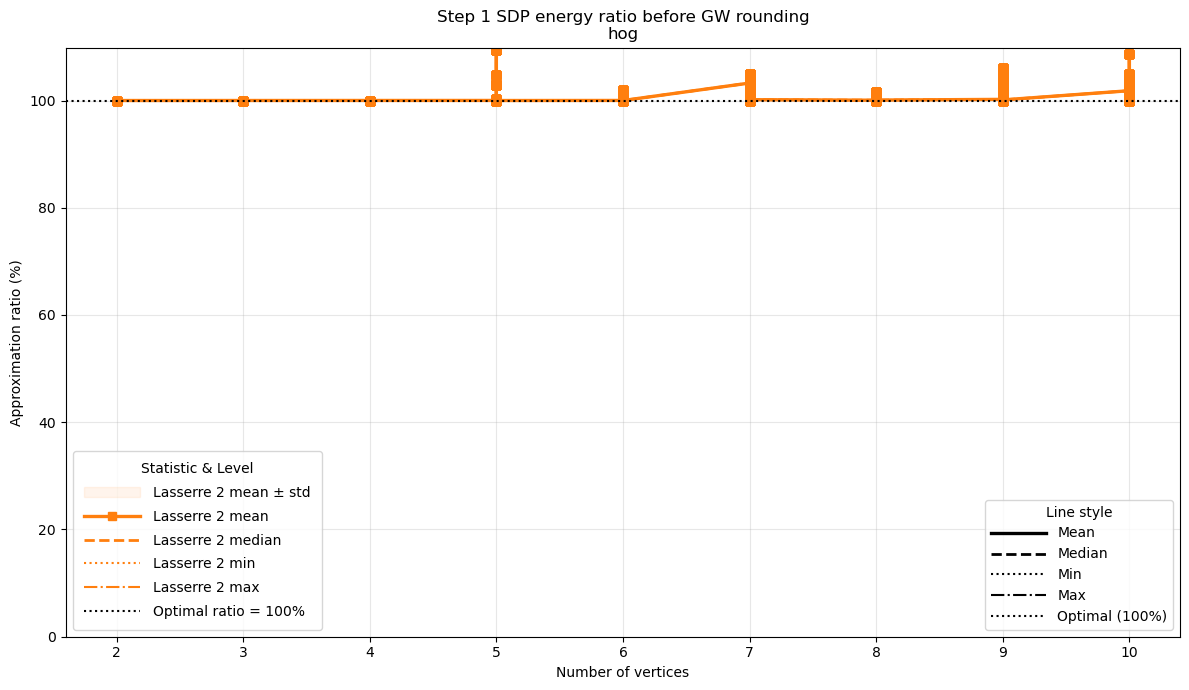

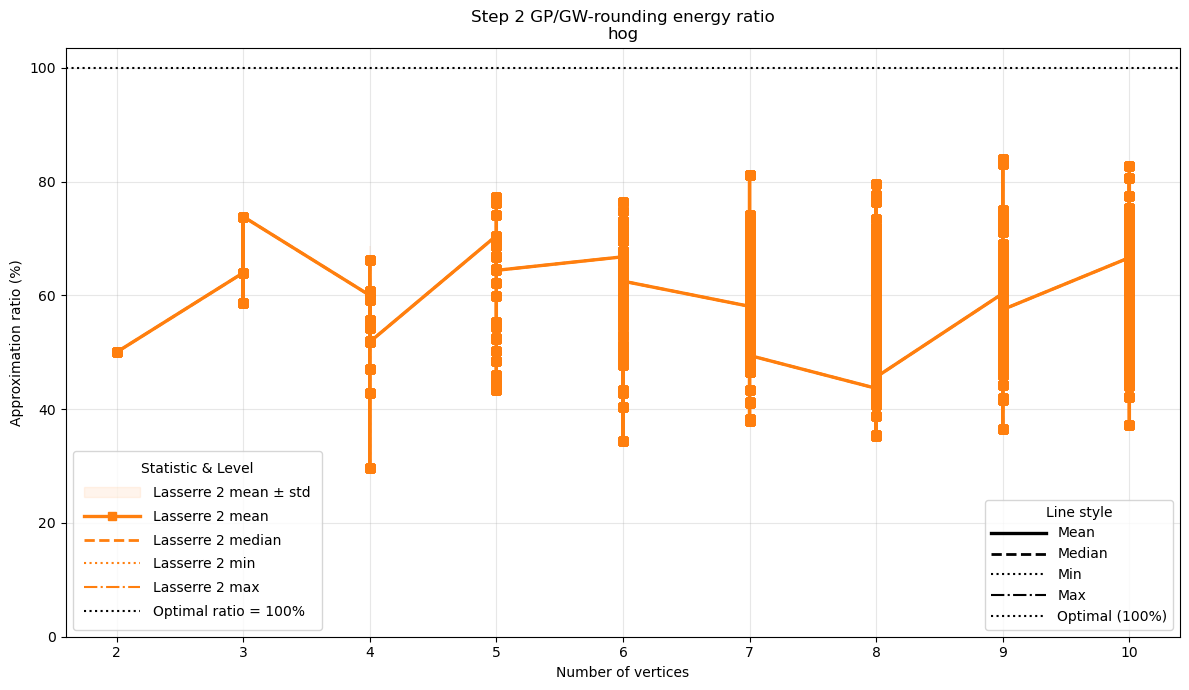

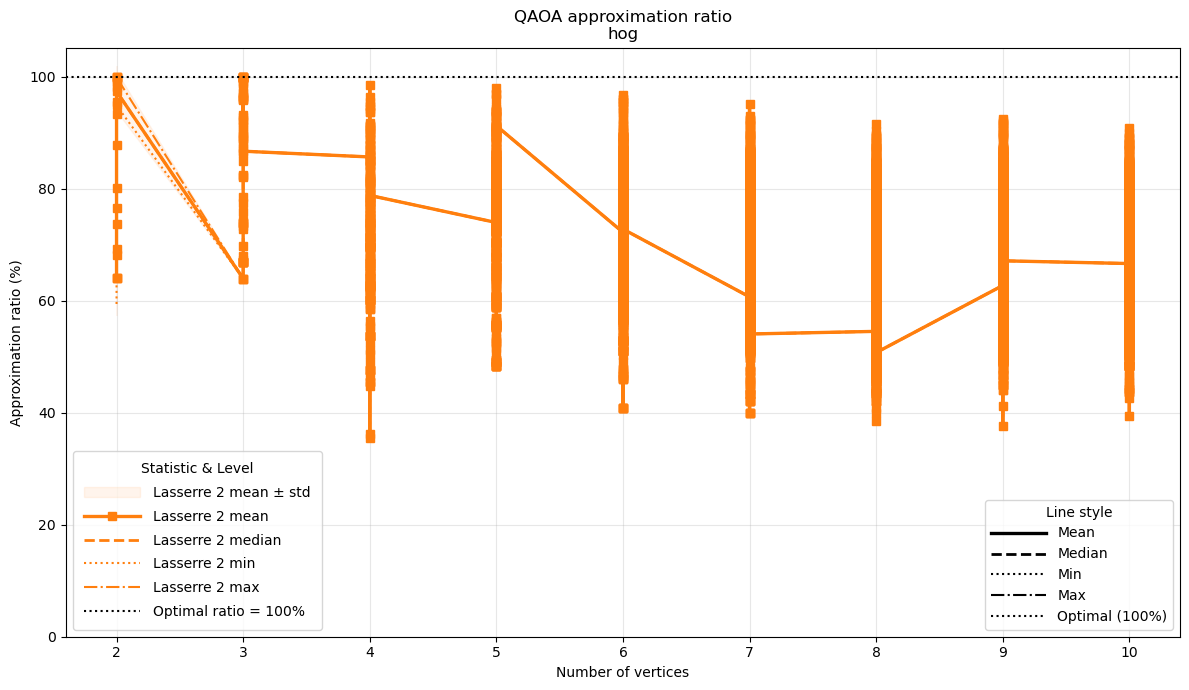

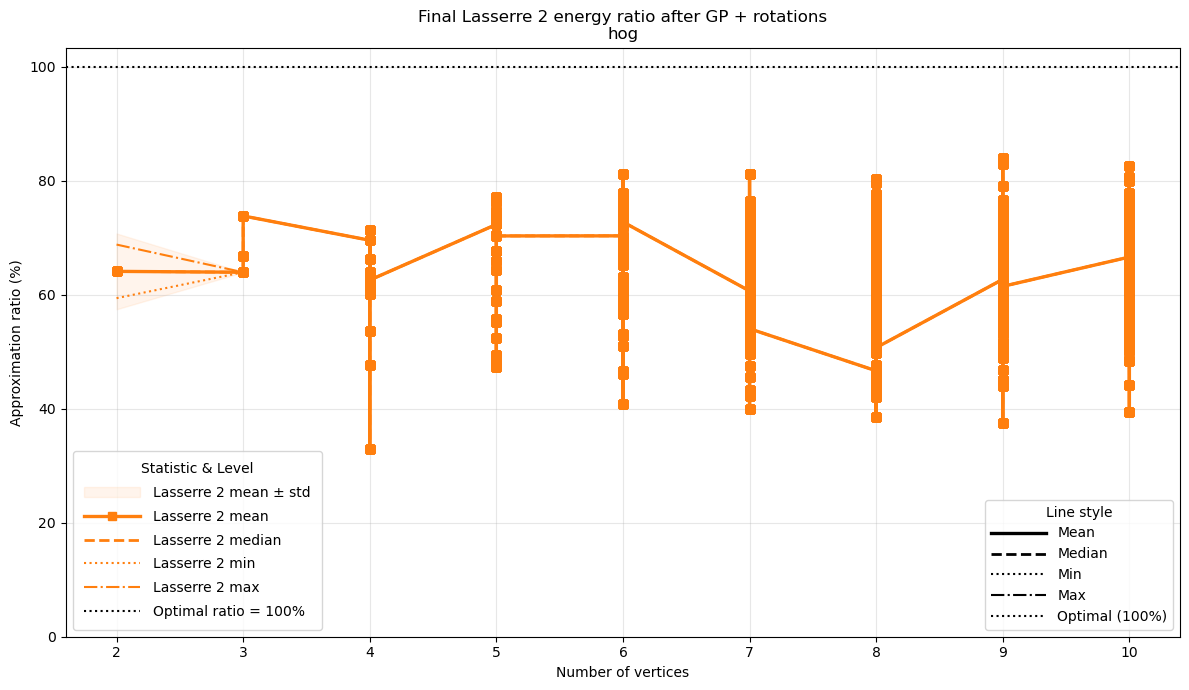

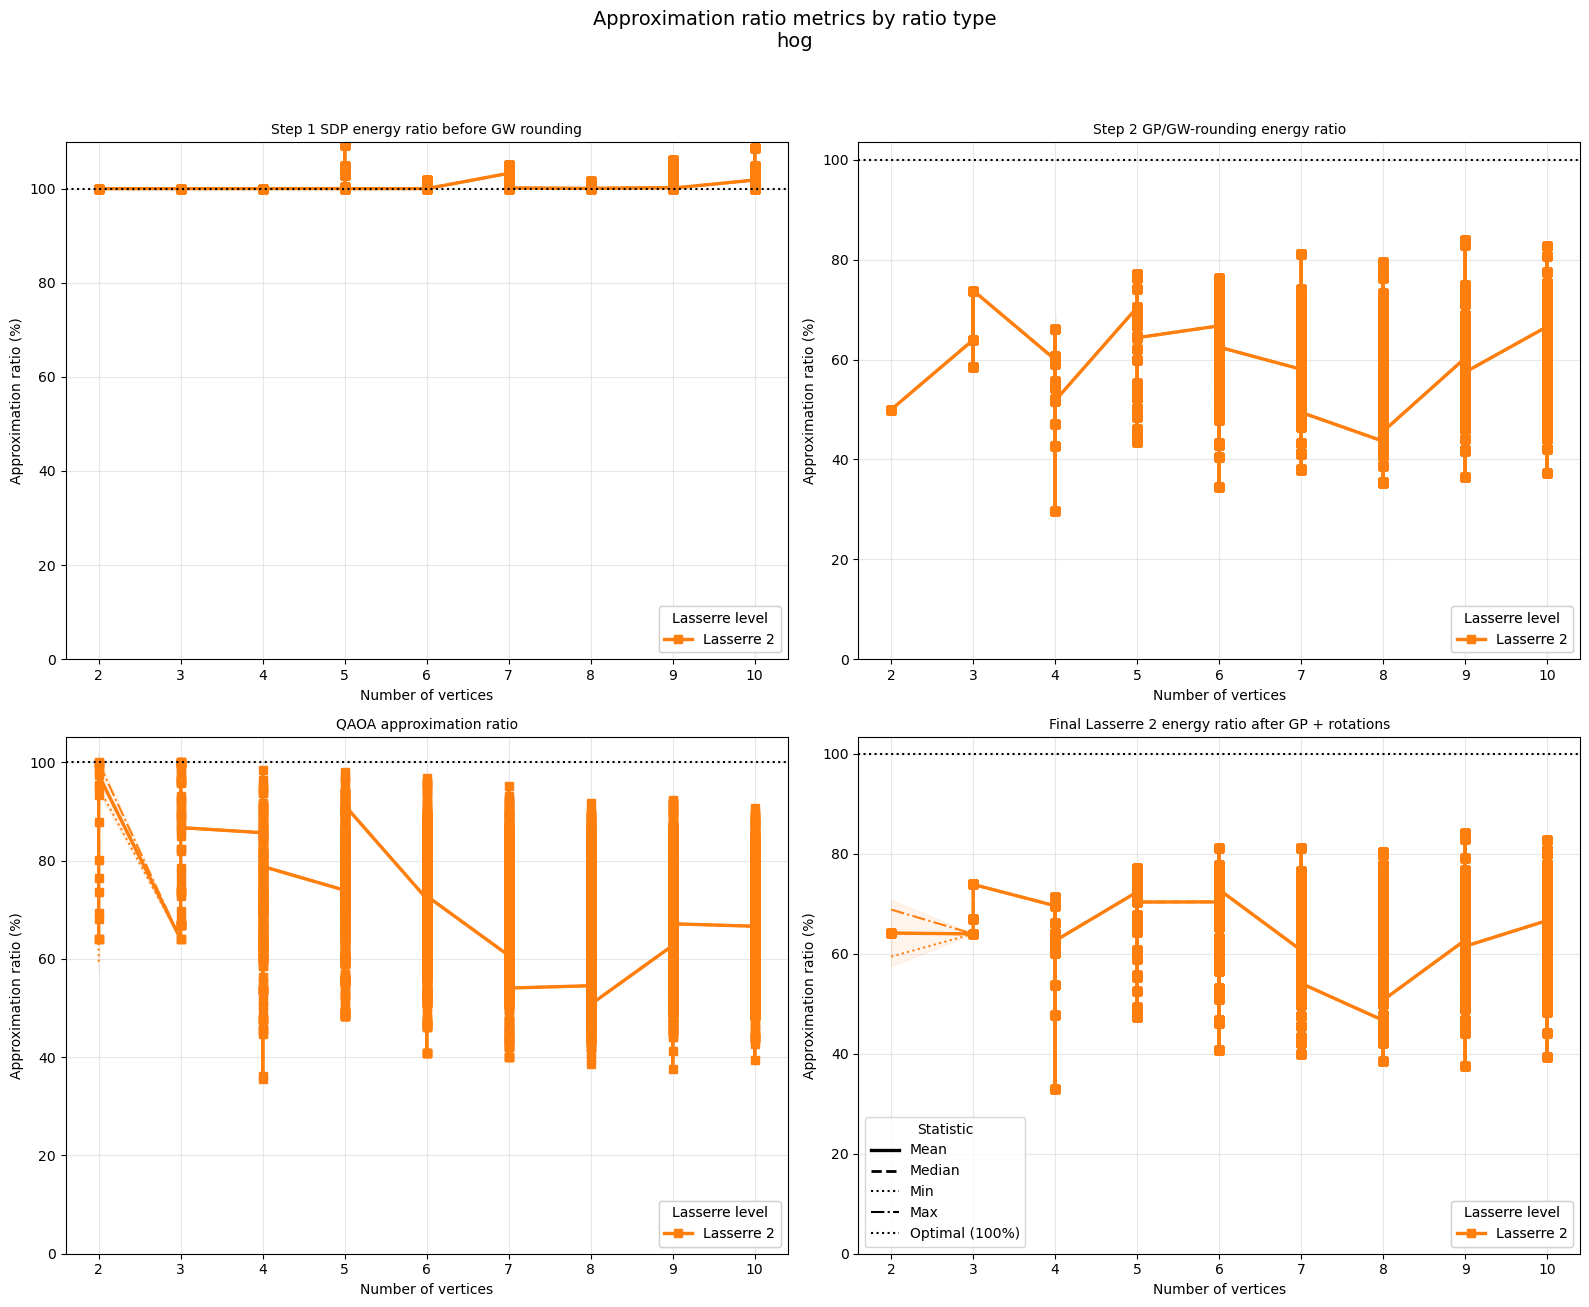

In [43]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
from matplotlib.lines import Line2D

# -----------------------------
# Plot output options
# -----------------------------
save_ratio_type_plots = False
ratio_type_plot_output_dir = Path("ratio_type_plots")
ratio_type_plot_output_dir.mkdir(exist_ok=True)

# -----------------------------
# Helpers
# -----------------------------
def parse_json_cell(cell):
    if cell is None or pd.isna(cell):
        return {}
    if isinstance(cell, dict):
        return cell
    return json.loads(cell)

def extract_stats(cell):
    """
    Extract min/mean/median/max/std/count from one compact stats cell.
    Values are returned as raw ratios, not percentages.
    """
    payload = parse_json_cell(cell)

    def get_float(key):
        value = payload.get(key)
        if value is None:
            return None
        try:
            return float(value)
        except Exception:
            return None

    return {
        "min": get_float("min"),
        "mean": get_float("mean"),
        "median": get_float("median"),
        "max": get_float("max"),
        "std": get_float("std"),
        "count": payload.get("count", 0),
    }

def extract_graph_info(row):
    return parse_json_cell(row["graph_instance"])

def setting_signature_without_graph_size(graph_info: dict) -> str:
    settings = graph_info.get("settings", {}).copy()
    for key in ["n", "m", "edges", "weights", "edge_weight_dict", "hog_graph_index"]:
        settings.pop(key, None)
    signature_payload = {
        "graph_type": graph_info.get("graph_type") or graph_info.get("type", "unknown"),
        # "settings": settings,  # keep this commented out if you want grouping only by graph_type
    }
    return json.dumps(signature_payload, sort_keys=True)

def short_setting_title(signature: str, max_len: int = 140) -> str:
    payload = json.loads(signature)
    graph_type = payload.get("graph_type", "unknown")
    settings = payload.get("settings", {})

    important_keys = [
        "p",
        "precision/iterations",
        "parameter_vector",
        "optimiser",
        "circuit_type",
        "warm_start_mode",
        "weighted",
    ]
    parts = [f"{k}={settings.get(k)}" for k in important_keys if k in settings]
    title = f"{graph_type}" if not parts else f"{graph_type} | " + ", ".join(parts)
    return title if len(title) <= max_len else title[: max_len - 3] + "..."

def add_stats_columns(df: pd.DataFrame, source_col: str, prefix: str) -> pd.DataFrame:
    stats = df[source_col].apply(extract_stats)
    df[f"{prefix}_min"] = stats.apply(lambda x: x["min"])
    df[f"{prefix}_mean"] = stats.apply(lambda x: x["mean"])
    df[f"{prefix}_median"] = stats.apply(lambda x: x["median"])
    df[f"{prefix}_max"] = stats.apply(lambda x: x["max"])
    df[f"{prefix}_std"] = stats.apply(lambda x: x["std"])
    df[f"{prefix}_count"] = stats.apply(lambda x: x["count"])
    return df

def plot_one_level_with_stats(
    ax,
    group: pd.DataFrame,
    prefix: str,
    label: str,
    color: str,
    mean_linestyle,
    marker: str,
):
    """
    Plot mean, median, min, max (in percentages) plus mean ± std shading for one “level”
    (Lasserre 1 or Lasserre 2). Lines are distinguished by style; colors differentiate L1 vs L2.
    """
    x = group["n_vertices"].astype(int)
    mean = group[f"{prefix}_mean"] * 100
    median = group[f"{prefix}_median"] * 100
    min_y = group[f"{prefix}_min"] * 100
    max_y = group[f"{prefix}_max"] * 100
    std = group[f"{prefix}_std"] * 100

    valid = mean.notna()
    if valid.sum() == 0:
        return False

    x_valid = x[valid]
    mean_valid = mean[valid]
    median_valid = median[valid]
    min_valid = min_y[valid]
    max_valid = max_y[valid]
    std_valid = std[valid]

    # Optional: shade mean ± std band
    if std_valid.notna().any():
        lower = (mean_valid - std_valid).clip(lower=0)
        upper = mean_valid + std_valid
        ax.fill_between(
            x_valid,
            lower,
            upper,
            alpha=0.08,
            color=color,
            label=f"{label} mean ± std",
        )

    # Lines for min, max, mean, median
    # Mean line: same style for both L1 and L2, specified by mean_linestyle
    ax.plot(
        x_valid,
        mean_valid,
        label=f"{label} mean",
        color=color,
        linestyle=mean_linestyle,
        marker=marker,
        linewidth=2.4,
        markersize=6,
    )

    # Median line: dashed
    if median_valid.notna().any():
        ax.plot(
            x_valid,
            median_valid,
            label=f"{label} median",
            color=color,
            linestyle="--",
            marker=None,
            linewidth=2.0,
        )

    # Min line: dotted
    if min_valid.notna().any():
        ax.plot(
            x_valid,
            min_valid,
            label=f"{label} min",
            color=color,
            linestyle=":",
            marker=None,
            linewidth=1.5,
        )

    # Max line: dash-dot
    if max_valid.notna().any():
        ax.plot(
            x_valid,
            max_valid,
            label=f"{label} max",
            color=color,
            linestyle="-.",
            marker=None,
            linewidth=1.5,
        )

    return True

# -----------------------------
# Prepare dataframe
# -----------------------------
plot_df = comparison_df.copy()

if plot_df.empty:
    raise ValueError(
        "comparison_df is empty. If L1 and L2 cover different settings, set "
        "ONLY_COMMON_SETTINGS=False and rerun the aggregation cell."
    )

plot_df["_graph_info"] = plot_df.apply(extract_graph_info, axis=1)
plot_df["graph_type"] = plot_df["_graph_info"].apply(lambda x: x.get("graph_type") or x.get("type"))
plot_df["n_vertices"] = plot_df["_graph_info"].apply(lambda x: x.get("#vertices") or x.get("n"))
plot_df["n_edges"] = plot_df["_graph_info"].apply(lambda x: x.get("#edges") or x.get("m"))
plot_df["_setting_signature"] = plot_df["_graph_info"].apply(setting_signature_without_graph_size)

#plot_df = plot_df[plot_df["graph_type"] == "line"].copy()

if plot_df.empty:
    raise ValueError("No line graph rows found in comparison_df.")

# -----------------------------
# Ratio types: one plot each
# -----------------------------
LEVEL_COLOR_STYLES = {
    "Lasserre 1": {"color": "tab:blue", "marker": "o"},
    "Lasserre 2": {"color": "tab:orange", "marker": "s"},
}


def color_handles_for_levels(level_names):
    handles = []
    for level_name in level_names:
        style = LEVEL_COLOR_STYLES.get(level_name)
        if style is None:
            continue
        handles.append(
            Line2D(
                [0],
                [0],
                color=style["color"],
                marker=style["marker"],
                linestyle="-",
                linewidth=2.4,
                label=level_name,
            )
        )
    return handles


ratio_type_specs = {
    "step1": {
        "title": "Step 1 SDP energy ratio before GW rounding",
        "l1_col": "Lasserre 1 Step 1 SDP energy approx. ratio (before GW rounding)",
        "l2_col": "Lasserre 2 Step 1 SDP energy approx. ratio (before GW rounding)",
    },
    "gp_rounding": {
        "title": "Step 2 GP/GW-rounding energy ratio",
        "l1_col": "Lasserre 1 Step 2 pre-rotation GP/GW energy approx. ratio",
        "l2_col": "Lasserre 2 Step 2 pre-rotation GP/GW energy approx. ratio",
    },
    "qaoa": {
        "title": "QAOA approximation ratio",
        "l1_col": "Lasserre 1 QAOA approx. ratio",
        "l2_col": "Lasserre 2 QAOA approx. ratio",
    },
    "rotations": {
        "title": "Final Lasserre 2 energy ratio after GP + rotations",
        "l1_col": None,
        "l2_col": "Lasserre 2 Algorithm 17 statevector approx. ratio after rotations",
    },
}

# -----------------------------
# One plot per ratio type and benchmark setting
# -----------------------------
for setting_idx, (setting_signature, setting_group) in enumerate(plot_df.groupby("_setting_signature"), start=1):
    setting_group = setting_group.sort_values("n_vertices").reset_index(drop=True)

    for ratio_name, ratio_spec in ratio_type_specs.items():
        group = setting_group.copy()

        l1_col = ratio_spec["l1_col"]
        l2_col = ratio_spec["l2_col"]

        has_l1 = l1_col is not None and l1_col in group.columns
        has_l2 = l2_col is not None and l2_col in group.columns

        if not has_l1 and not has_l2:
            print(f"Skipping {ratio_name}: required columns missing.")
            continue

        # Compute stats for L1 and L2 columns
        if has_l1:
            group = add_stats_columns(group, l1_col, "l1")
        if has_l2:
            group = add_stats_columns(group, l2_col, "l2")

        fig, ax = plt.subplots(figsize=(12, 7))

        any_line = False

        # Use same line style for mean across L1 and L2
        if has_l1:
            any_line |= plot_one_level_with_stats(
                ax=ax,
                group=group,
                prefix="l1",
                label="Lasserre 1",
                color="tab:blue",
                mean_linestyle="-",
                marker="o",
            )

        if has_l2:
            any_line |= plot_one_level_with_stats(
                ax=ax,
                group=group,
                prefix="l2",
                label="Lasserre 2",
                color="tab:orange",
                mean_linestyle="-",
                marker="s",
            )

        if not any_line:
            print(f"Skipping {ratio_name}: no numeric ratio values available.")
            plt.close(fig)
            continue

        ax.axhline(
            100.0,
            linestyle=":",
            linewidth=1.5,
            color="black",
            label="Optimal ratio = 100%",
        )

        title = short_setting_title(setting_signature)
        ax.set_title(f"{ratio_spec['title']}\n{title}")
        ax.set_xlabel("Number of vertices")
        ax.set_ylabel("Approximation ratio (%)")
        ax.set_ylim(bottom=0)

        unique_x = sorted(group["n_vertices"].dropna().astype(int).unique())
        ax.set_xticks(unique_x)
        ax.grid(True, alpha=0.3)

        # Build legends
        # Main legend: all plotted lines (handles from ax.plot / fill_between)
        handles, labels = ax.get_legend_handles_labels()
        # Style legend: show line styles for Mean, Median, Min, Max
        style_handles = [
            Line2D([0], [0], color="black", linestyle="-", linewidth=2.4, label="Mean"),
            Line2D([0], [0], color="black", linestyle="--", linewidth=2.0, label="Median"),
            Line2D([0], [0], color="black", linestyle=":", linewidth=1.5, label="Min"),
            Line2D([0], [0], color="black", linestyle="-.", linewidth=1.5, label="Max"),
            Line2D([0], [0], color="black", linestyle=":", linewidth=1.5, label="Optimal (100%)"),
        ]

        main_legend = ax.legend(handles=handles, loc="best", handlelength=4.0, handletextpad=1.0, borderpad=0.8, labelspacing=0.7, title="Statistic & Level")
        ax.add_artist(main_legend)

        ax.legend(
            handles=style_handles,
            loc="lower right",
            handlelength=4.0,
            title="Line style",
        )

        plt.tight_layout()

        if save_ratio_type_plots:
            filename = f"ratio_type_{ratio_name}_setting_{setting_idx:03d}.png"
            path = ratio_type_plot_output_dir / filename
            fig.savefig(path, dpi=200, bbox_inches="tight")
            print(f"Saved: {path}")

        plt.show()

# -----------------------------
# Combined plot: 4 ratio types per benchmark setting
# -----------------------------
for setting_idx, (setting_signature, setting_group) in enumerate(plot_df.groupby("_setting_signature"), start=1):
    setting_group = setting_group.sort_values("n_vertices").reset_index(drop=True)

    # Create a 2x2 figure for all ratio types
    fig, axes = plt.subplots(2, 2, figsize=(16, 14))
    ratio_order = ["step1", "gp_rounding", "qaoa", "rotations"]
    for idx, ratio_name in enumerate(ratio_order):
        row_idx, col_idx = divmod(idx, 2)
        ax = axes[row_idx][col_idx]

        ratio_spec = ratio_type_specs.get(ratio_name, {})
        l1_col = ratio_spec.get("l1_col")
        l2_col = ratio_spec.get("l2_col")

        group = setting_group.copy()
        has_l1 = l1_col is not None and l1_col in group.columns
        has_l2 = l2_col is not None and l2_col in group.columns

        if has_l1:
            group = add_stats_columns(group, l1_col, "l1")
        if has_l2:
            group = add_stats_columns(group, l2_col, "l2")

        any_line = False
        plotted_levels = []
        if has_l1:
            plotted_l1 = plot_one_level_with_stats(
                ax=ax,
                group=group,
                prefix="l1",
                label="Lasserre 1",
                color="tab:blue",
                mean_linestyle="-",
                marker="o",
            )
            any_line |= plotted_l1
            if plotted_l1:
                plotted_levels.append("Lasserre 1")
        if has_l2:
            plotted_l2 = plot_one_level_with_stats(
                ax=ax,
                group=group,
                prefix="l2",
                label="Lasserre 2",
                color="tab:orange",
                mean_linestyle="-",
                marker="s",
            )
            any_line |= plotted_l2
            if plotted_l2:
                plotted_levels.append("Lasserre 2")

        # Add horizontal line at 100%
        ax.axhline(
            100.0,
            linestyle=":",
            linewidth=1.5,
            color="black",
            label="Optimal (100%)",
        )

        ax.set_xlabel("Number of vertices")
        ax.set_ylabel("Approximation ratio (%)")
        ax.set_ylim(bottom=0)
        unique_x = sorted(group["n_vertices"].dropna().astype(int).unique())
        ax.set_xticks(unique_x)
        ax.grid(True, alpha=0.3)

        # Title for each subplot
        ax.set_title(ratio_type_specs[ratio_name]["title"], fontsize=10)

        # Style legend: same for all subplots
        if idx == len(ratio_order) - 1:
            style_legend = ax.legend(handles=style_handles, loc="lower left", title="Statistic")
            ax.add_artist(style_legend)

        color_handles = color_handles_for_levels(plotted_levels)
        if color_handles:
            color_legend = ax.legend(handles=color_handles, loc="lower right", title="Lasserre level")
            ax.add_artist(color_legend)
    # Top title for combined figure
    combined_title = short_setting_title(setting_signature)
    fig.suptitle(f"Approximation ratio metrics by ratio type\n{combined_title}", fontsize=14)
    plt.tight_layout(rect=[0, 0.05, 1, 0.95])
    plt.show()

Number of plot groups: 1
      graph_type  n_vertices  n_edges         _setting_signature
0            hog           2        1  {"graph_type": "unknown"}
20           hog           3        2  {"graph_type": "unknown"}
40           hog           3        3  {"graph_type": "unknown"}
80           hog           4        3  {"graph_type": "unknown"}
160          hog           4        4  {"graph_type": "unknown"}
...          ...         ...      ...                        ...
12830        hog          10       25  {"graph_type": "unknown"}
14018        hog          10       30  {"graph_type": "unknown"}
14428        hog          10       35  {"graph_type": "unknown"}
14523        hog          10       40  {"graph_type": "unknown"}
14543        hog          10       45  {"graph_type": "unknown"}

[81 rows x 4 columns]


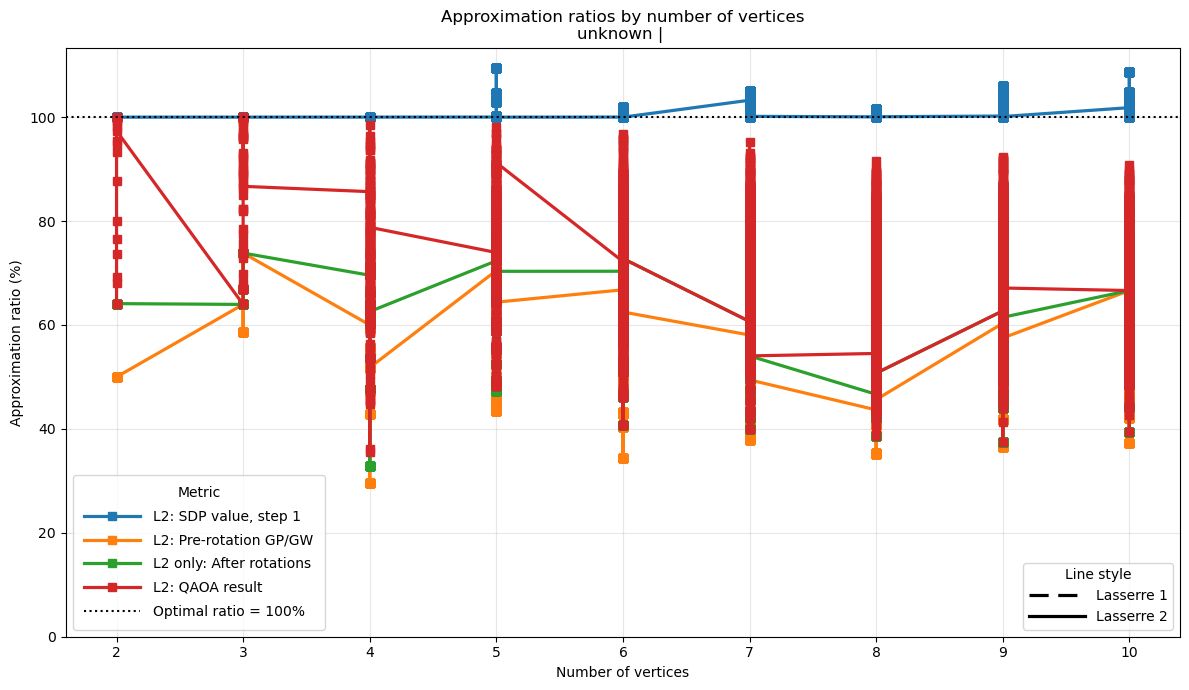

In [44]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
from matplotlib.lines import Line2D


# -----------------------------
# Plot output options
# -----------------------------
save_plots = False
plot_output_dir = Path("ratio_plots")
plot_output_dir.mkdir(exist_ok=True)


# -----------------------------
# Helpers
# -----------------------------
def parse_json_cell(cell):
    if cell is None or pd.isna(cell):
        return {}
    if isinstance(cell, dict):
        return cell
    return json.loads(cell)


def extract_stat(cell, stat="mean"):
    payload = parse_json_cell(cell)
    value = payload.get(stat)
    if value is None:
        return None
    try:
        return float(value)
    except Exception:
        return None


def extract_graph_info(row):
    return parse_json_cell(row["graph_instance"])


def setting_signature_without_graph_size(graph_info: dict) -> str:
    """
    One benchmark setting = same graph type and same algorithmic settings.
    n/m/edges vary along the x-axis.
    """
    settings = graph_info.get("settings", {}).copy()

    for key in [
        "n",
        "m",
        "edges",
        "weights",
        "edge_weight_dict",
        "hog_graph_index",
    ]:
        settings.pop(key, None)

    signature_payload = {
        "graph_type": graph_info.get("type", "unknown"),
        #"settings": settings,
    }

    return json.dumps(signature_payload, sort_keys=True)


def short_setting_title(signature: str, max_len: int = 140) -> str:
    payload = json.loads(signature)

    graph_type = payload.get("graph_type", "unknown")
    settings = payload.get("settings", {})

    important_keys = [
        "p",
        "precision/iterations",
        "parameter_vector",
        "optimiser",
        "circuit_type",
        "warm_start_mode",
        "weighted",
    ]

    parts = [f"{k}={settings.get(k)}" for k in important_keys if k in settings]
    title = f"{graph_type} | " + ", ".join(parts)

    if len(title) > max_len:
        title = title[:max_len - 3] + "..."

    return title


# -----------------------------
# Prepare plotting dataframe
# -----------------------------
plot_df = comparison_df.copy()

plot_df["_graph_info"] = plot_df.apply(extract_graph_info, axis=1)
plot_df["graph_type"] = plot_df["_graph_info"].apply(lambda x: x.get("graph_type"))
plot_df["n_vertices"] = plot_df["_graph_info"].apply(lambda x: x.get("#vertices"))
plot_df["n_edges"] = plot_df["_graph_info"].apply(lambda x: x.get("#edges"))

# Correct: one setting can contain several n values.
plot_df["_setting_signature"] = plot_df["_graph_info"].apply(setting_signature_without_graph_size)

# For now only line graphs.
#plot_df = plot_df[plot_df["graph_type"] == "line"].copy()

if plot_df.empty:
    raise ValueError("No line graph rows found in comparison_df.")

print("Number of plot groups:", plot_df["_setting_signature"].nunique())
print(
    plot_df[["graph_type", "n_vertices", "n_edges", "_setting_signature"]]
    .drop_duplicates()
    .sort_values(["n_vertices", "n_edges"])
)


# -----------------------------
# Ratio columns to plot
# -----------------------------
ratio_specs = {
    "step1_l1": {
        "column": "Lasserre 1 Step 1 SDP energy approx. ratio (before GW rounding)",
        "label": "SDP value, step 1",
        "level": "L1",
        "color": "tab:blue",
        "linestyle": (0, (6, 3)),   # visibly dashed
        "marker": "o",
    },
    "step1_l2": {
        "column": "Lasserre 2 Step 1 SDP energy approx. ratio (before GW rounding)",
        "label": "SDP value, step 1",
        "level": "L2",
        "color": "tab:blue",
        "linestyle": "-",
        "marker": "s",
    },
    "rounding_l1": {
        "column": "Lasserre 1 Step 2 pre-rotation GP/GW energy approx. ratio",
        "label": "Pre-rotation GP/GW",
        "level": "L1",
        "color": "tab:orange",
        "linestyle": (0, (6, 3)),
        "marker": "o",
    },
    "rounding_l2": {
        "column": "Lasserre 2 Step 2 pre-rotation GP/GW energy approx. ratio",
        "label": "Pre-rotation GP/GW",
        "level": "L2",
        "color": "tab:orange",
        "linestyle": "-",
        "marker": "s",
    },
    "rotations_l2": {
        "column": "Lasserre 2 Algorithm 17 statevector approx. ratio after rotations",
        "label": "After rotations",
        "level": "L2 only",
        "color": "tab:green",
        "linestyle": "-",
        "marker": "s",
    },
    "qaoa_l1": {
        "column": "Lasserre 1 QAOA approx. ratio",
        "label": "QAOA result",
        "level": "L1",
        "color": "tab:red",
        "linestyle": (0, (6, 3)),
        "marker": "o",
    },
    "qaoa_l2": {
        "column": "Lasserre 2 QAOA approx. ratio",
        "label": "QAOA result",
        "level": "L2",
        "color": "tab:red",
        "linestyle": "-",
        "marker": "s",
    },
}

for spec in ratio_specs.values():
    col = spec["column"]
    out_col = col + "_mean"

    if col in plot_df.columns:
        plot_df[out_col] = plot_df[col].apply(lambda cell: extract_stat(cell, "mean"))
    else:
        plot_df[out_col] = None


# -----------------------------
# One plot per benchmark setting
# -----------------------------
for setting_idx, (setting_signature, group) in enumerate(plot_df.groupby("_setting_signature"), start=1):
    group = group.sort_values("n_vertices").reset_index(drop=True)

    fig, ax = plt.subplots(figsize=(12, 7))

    x = group["n_vertices"].astype(int)
    any_line = False

    for _, spec in ratio_specs.items():
        y_col = spec["column"] + "_mean"
        y = group[y_col] * 100

        valid = y.notna()
        if valid.sum() == 0:
            continue

        any_line = True

        full_label = f"{spec['level']}: {spec['label']}"

        ax.plot(
            x[valid],
            y[valid],
            label=full_label,
            color=spec["color"],
            linestyle=spec["linestyle"],
            marker=spec["marker"],
            linewidth=2.3,
            markersize=6,
        )

    if not any_line:
        print(f"Skipping setting {setting_idx}: no ratio values available.")
        plt.close(fig)
        continue

    ax.axhline(
        100.0,
        linestyle=":",
        linewidth=1.5,
        color="black",
        label="Optimal ratio = 100%",
    )

    title = short_setting_title(setting_signature)
    ax.set_title(f"Approximation ratios by number of vertices\n{title}")
    ax.set_xlabel("Number of vertices")
    ax.set_ylim(bottom=0)
    ax.set_ylabel("Approximation ratio (%)")

    unique_x = sorted(group["n_vertices"].dropna().astype(int).unique())
    ax.set_xticks(unique_x)

    ax.grid(True, alpha=0.3)

    # Main legend: actual plotted lines.
    main_legend = ax.legend(
        loc="best",
        handlelength=4.0,     # makes dashed lines visible
        handletextpad=1.0,
        borderpad=0.8,
        labelspacing=0.7,
        title="Metric",
    )
    ax.add_artist(main_legend)

    # Extra legend: visual rule for line styles.
    style_handles = [
        Line2D([0], [0], color="black", linestyle=(0, (6, 3)), linewidth=2.3, label="Lasserre 1"),
        Line2D([0], [0], color="black", linestyle="-", linewidth=2.3, label="Lasserre 2"),
    ]

    ax.legend(
        handles=style_handles,
        loc="lower right",
        handlelength=4.0,
        title="Line style",
    )

    plt.tight_layout()

    if save_plots:
        filename = f"ratio_plot_setting_{setting_idx:03d}.png"
        path = plot_output_dir / filename
        fig.savefig(path, dpi=200, bbox_inches="tight")
        print(f"Saved: {path}")

    plt.show()

TypeError: 'str' object is not callable

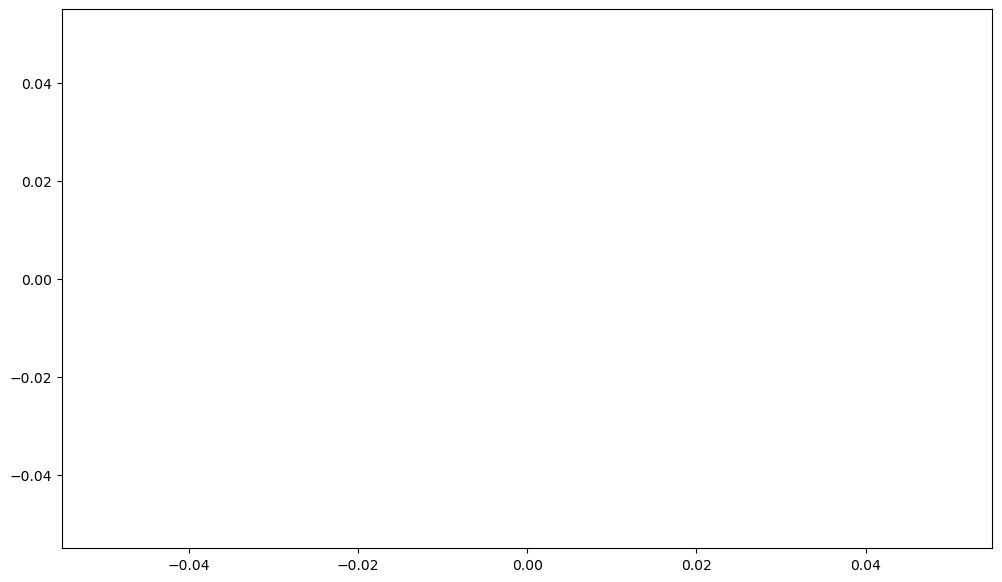

In [45]:
import json
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

# -----------------------------
# Helpers (same as before)
# -----------------------------
def parse_json_cell(cell):
    if cell is None or pd.isna(cell):
        return {}
    if isinstance(cell, dict):
        return cell
    return json.loads(cell)

def extract_stat(cell, stat="mean"):
    payload = parse_json_cell(cell)
    value = payload.get(stat)
    return float(value) if value is not None else None

def extract_graph_info(row):
    return parse_json_cell(row["graph_instance"])

# Keep only line graphs for this plotting
plot_df = comparison_df.copy()
plot_df["_graph_info"] = plot_df.apply(extract_graph_info, axis=1)
plot_df["graph_type"] = plot_df["_graph_info"].apply(lambda x: x.get("graph_type"))
#plot_df = plot_df[plot_df["graph_type"] == "line"].copy()

# Extract n_vertices
plot_df["n_vertices"] = plot_df["_graph_info"].apply(lambda x: x.get("#vertices"))

# Define the ratio specs: one entry per ratio type (same as earlier)
ratio_specs = {
    "step1": {
        "column": "Lasserre 1 Step 1 SDP energy approx. ratio (before GW rounding)",
        "column2": "Lasserre 2 Step 1 SDP energy approx. ratio (before GW rounding)",
        "title": "Step 1 SDP approximation ratio (before GW rounding)",
        "color": "tab:blue",
    },
    "rounding": {
        "column": "Lasserre 1 Step 2 pre-rotation GP/GW energy approx. ratio",
        "column2": "Lasserre 2 Step 2 pre-rotation GP/GW energy approx. ratio",
        "title": "Step 2 GP/GW rounding approximation ratio",
        "color": "tab:orange",
    },
    "rotations": {
        "column": None,  # no Lasserre 1 equivalent for this stage
        "column2": "Lasserre 2 Algorithm 17 statevector approx. ratio after rotations",
        "title": "Step 2 after rotations approximation ratio (L2 only)",
        "color": "tab:green",
    },
    "qaoa": {
        "column": "Lasserre 1 QAOA approx. ratio",
        "column2": "Lasserre 2 QAOA approx. ratio",
        "title": "QAOA approximation ratio",
        "color": "tab:red",
    },
}

# Extract statistics columns for each ratio type
stats = ["min", "mean", "median", "max", "std"]
for spec_key, spec in ratio_specs.items():
    for level_name, col_name in zip(["L1", "L2"], [spec["column"], spec["column2"]]):
        if col_name:
            for stat in stats:
                new_col = f"{col_name}_{stat}"
                plot_df[new_col] = plot_df[col_name].apply(lambda cell, s=stat: extract_stat(cell, s))

# Plot each ratio type separately
for spec_key, spec in ratio_specs.items():
    fig, ax = plt.subplots(figsize=(12, 7))
    has_data = False

    # Loop over each Lasserre level separately (L1 and L2)
    for level_name, col_name, style in [
        ("L1", spec.get("column"), (0, (6, 3))),  # dashed
        ("L2", spec.get("column2"), "-"),        # solid
    ]:
        if not col_name:
            # skip L1 if there is no L1 equivalent for this ratio type
            continue

        # Extract stats for this level
        grouped = plot_df[plot_df[col_name].notna()].sort_values("n_vertices")

        if grouped.empty:
            continue

        x = grouped["n_vertices"].astype(int)

        # Plot min, median, mean, and max individually
        y_min = grouped[f"{col_name}_min"] * 100
        y_median = grouped[f"{col_name}_median"] * 100
        y_mean = grouped[f"{col_name}_mean"] * 100
        y_max = grouped[f"{col_name}_max"] * 100
        y_std = grouped[f"{col_name}_std"] * 100

        # Plot min/max as dotted lines
        ax.plot(x, y_min, linestyle=":", color=spec["color"], alpha=0.7,
                marker="v", label=f"{spec['title']} {level_name} min")
        ax.plot(x, y_max, linestyle=":", color=spec["color"], alpha=0.7,
                marker="^", label=f"{spec['title']} {level_name} max")

        # Plot mean and median with thicker lines and specified style
        ax.plot(
            x,
            y_mean,
            label=f"{spec['title']} {level_name} mean",
            color=spec["color"],
            linestyle=style,
            marker="o",
            linewidth=2.0,
        )
        ax.plot(
            x,
            y_median,
            label(f"{spec['title']} {level_name} median"),
            color=spec["color"],
            linestyle=style,
            marker="s",
            linewidth=2.0,
        )

        # Shade ±std around mean
        lower = y_mean - y_std
        upper = y_mean + y_std
        ax.fill_between(
            x,
            lower,
            upper,
            alpha=0.15,
            color=spec["color"],
        )

        has_data = True

    if not has_data:
        plt.close(fig)
        continue

    ax.axhline(100.0, color="black", linestyle=":", linewidth=1.5, label="Optimal ratio = 100%")
    ax.set_xlabel("Number of vertices")
    ax.set_ylabel("Approximation ratio (%)")
    ax.set_ylim(bottom=0)
    ax.set_xticks(sorted(plot_df["n_vertices"].dropna().astype(int).unique()))
    ax.set_title(spec["title"])

    # Arrange the legend properly
    ax.legend(loc="best", handlelength=3.0)

    plt.grid(alpha=0.3)
    plt.tight_layout()

    # Uncomment to save plots to disk
    # fig.savefig(plot_output_dir / f"ratio_{spec_key}.png", dpi=200)

    plt.show()

In [ ]:
import json
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import pandas as pd

# Helper functions to parse JSON-like cells and extract stats
def parse_json_cell(cell):
    if cell is None or pd.isna(cell):
        return {}
    if isinstance(cell, dict):
        return cell
    return json.loads(cell)

def extract_stat(cell, stat="mean"):
    payload = parse_json_cell(cell)
    value = payload.get(stat)
    if value is None:
        return None
    try:
        return float(value)
    except Exception:
        return None

# Extract graph info for grouping
def extract_graph_info(row):
    return parse_json_cell(row["graph_instance"])

# Prepare dataframe with numeric graph fields
plot_df = comparison_df.copy()
plot_df["_graph_info"] = plot_df.apply(extract_graph_info, axis=1)
plot_df["graph_type"] = plot_df["_graph_info"].apply(lambda x: x.get("graph_type"))
plot_df["n_vertices"] = plot_df["_graph_info"].apply(lambda x: x.get("#vertices"))
plot_df["n_edges"] = plot_df["_graph_info"].apply(lambda x: x.get("#edges"))

# We will only plot line graphs here
#plot_df = plot_df[plot_df["graph_type"] == "line"].copy()
if plot_df.empty:
    raise ValueError("No line graph rows found in comparison_df.")

# Define ratio types with their L1/L2 columns and a base color
ratio_types = [
    {
        "ratio_key": "step1",
        "title": "Step 1 SDP energy approx. ratio (before GW rounding)",
        "columns": {
            "L1": "Lasserre 1 Step 1 SDP energy approx. ratio (before GW rounding)",
            "L2": "Lasserre 2 Step 1 SDP energy approx. ratio (before GW rounding)",
        },
        "color": "tab:blue",
    },
    {
        "ratio_key": "gp_rounding",
        "title": "Step 2 pre-rotation GP/GW energy approx. ratio",
        "columns": {
            "L1": "Lasserre 1 Step 2 pre-rotation GP/GW energy approx. ratio",
            "L2": "Lasserre 2 Step 2 pre-rotation GP/GW energy approx. ratio",
        },
        "color": "tab:orange",
    },
    {
        "ratio_key": "rotations",
        "title": "Final energy approx. ratio (after GP + rotations)",
        "columns": {
            "L2": "Lasserre 2 Algorithm 17 statevector approx. ratio after rotations",
        },
        "color": "tab:green",
    },
    {
        "ratio_key": "qaoa",
        "title": "QAOA result approx. ratio",
        "columns": {
            "L1": "Lasserre 1 QAOA approx. ratio",
            "L2": "Lasserre 2 QAOA approx. ratio",
        },
        "color": "tab:red",
    },
]

# Convert ratio columns to mean/median/min/max/std columns in numeric form
for ratio in ratio_types:
    for level, col in ratio["columns"].items():
        for stat in ["min", "mean", "median", "max", "std"]:
            out_col = f"{col}_{stat}"
            plot_df[out_col] = plot_df[col].apply(lambda cell: extract_stat(cell, stat))
            
# Convert ratio values to percentages (0–100) after extraction
def to_percent(series):
    return series.astype(float) * 100

# Generate one plot per ratio type
for ratio in ratio_types:
    ratio_title = ratio["title"]
    base_color = ratio["color"]
    fig, ax = plt.subplots(figsize=(12, 7))

    for level in ["L1", "L2"]:
        if level not in ratio["columns"]:
            continue

        col_name = ratio["columns"][level]
        # Extract per-stat series for this ratio column
        df_level = plot_df.copy()
        n_values = df_level["n_vertices"].astype(int)

        # We may have multiple rows for the same n_vertices; aggregate them by averaging stats per n
        # Group by n
        grouped = df_level.groupby(n_values)
        aggregated = {
            "n_vertices": [],
            "min": [],
            "mean": [],
            "median": [],
            "max": [],
            "std": [],
        }
        for n, group in grouped:
            aggregated["n_vertices"].append(n)
            # Average across rows for mean and median, min of mins, max of maxes, avg std
            aggregated["min"].append(group[f"{col_name}_min"].mean())
            aggregated["mean"].append(group[f"{col_name}_mean"].mean())
            aggregated["median"].append(group[f"{col_name}_median"].mean())
            aggregated["max"].append(group[f"{col_name}_max"].mean())
            aggregated["std"].append(group[f"{col_name}_std"].mean())

        # Convert to percentages
        n_vals = np.array(aggregated["n_vertices"])
        y_min = to_percent(pd.Series(aggregated["min"]))
        y_mean = to_percent(pd.Series(aggregated["mean"]))
        y_median = to_percent(pd.Series(aggregated["median"]))
        y_max = to_percent(pd.Series(aggregated["max"]))
        y_std = to_percent(pd.Series(aggregated["std"]))

        # Define style based on level (L1 vs L2)
        linestyle = (0, (6, 3)) if level == "L1" else "-"
        label_prefix = "L1" if level == "L1" else "L2"

        # Shade the full min–max range
        ax.fill_between(
            n_vals,
            y_min,
            y_max,
            color=base_color,
            alpha=0.15,
        )
        # Shade ±std around mean
        ax.fill_between(
            n_vals,
            y_mean - y_std,
            y_mean + y_std,
            color=base_color,
            alpha=0.25,
        )

        # Plot min and max as thin lines (semi-transparent)
        ax.plot(
            n_vals,
            y_min,
            linestyle=":",
            linewidth=1.0,
            color=base_color,
            alpha=0.5,
            label=f"{label_prefix} min",
        )
        ax.plot(
            n_vals,
            y_max,
            linestyle=":",
            linewidth=1.0,
            color=base_color,
            alpha=0.5,
            label=f"{label_prefix} max",
        )

        # Plot mean and median with thicker lines
        ax.plot(
            n_vals,
            y_mean,
            linestyle=linestyle,
            linewidth=2.5,
            color=base_color,
            marker="o" if level == "L1" else "s",
            label=f"{label_prefix} mean",
        )
        ax.plot(
            n_vals,
            y_median,
            linestyle=linestyle,
            linewidth=2.5,
            color=base_color,
            marker="^" if level == "L1" else "D",
            label=f"{label_prefix} median",
        )

    # Add horizontal line at 100% for the optimum
    ax.axhline(100.0, color="black", linestyle=":", linewidth=1.5, label="Optimal = 100%")

    # Set axes and title
    ax.set_xlabel("Number of vertices")
    ax.set_ylabel("Approximation ratio (%)")
    ax.set_title(f"Approximation ratio by ratio type: {ratio_title}")
    ax.set_ylim(bottom=0)
    ax.grid(True, alpha=0.3)
    ax.set_xticks(sorted(plot_df["n_vertices"].astype(int).unique()))

    # Combine handles to avoid duplicate labels
    handles, labels = ax.get_legend_handles_labels()
    unique_labels = {}
    for h, l in zip(handles, labels):
        if l not in unique_labels:
            unique_labels[l] = h
    ax.legend(
        unique_labels.values(),
        unique_labels.keys(),
        loc="best",
        handlelength=4.0,
        title="Statistics and Groups",
    )

    plt.tight_layout()
    plt.show()

## Cross-subexperiment QAOA comparison


In [ ]:
# -----------------------------
# Cross-subexperiment QAOA comparison
# -----------------------------
# Each series independently selects its subexperiment, benchmark setting, and method.
# Legends are generated as "<name addition> | <family>".
CROSS_EXPERIMENT_DATASET = "*"
CROSS_EXPERIMENT_ONLY_COMMON_INSTANCES = True

CROSS_EXPERIMENT_SERIES = [
    {
        "name_addition": "_Exp5_subexp1_zeroAngles",
        "setting": "lr05_noheuristic",
        "family": "L1M1",
    },
    {
        "name_addition": "_Exp5_subexp1_zeroAngles",
        "setting": "lr05_noheuristic",
        "family": "L2M2",
    },
    {
        "name_addition": "_Exp5_subexp1_zeroAngles",
        "setting": "lr05_noheuristic",
        "family": "QAOA_only",
    },
    {
        "name_addition": "_Exp5_subexp3_KingAmplified",
        "setting": "lr05_h1_s10",
        "family": "L2M2",
    },
]


def cross_experiment_label(spec: dict) -> str:
    return f"{spec['name_addition'].lstrip('_')} | {spec['family']}"


def cross_experiment_paths(spec: dict, dataset: str) -> list[Path]:
    root = EXP5 / spec["name_addition"].lstrip("_") / spec["setting"]
    return sorted(root.glob(f"{dataset}/*_{spec['family']}_clipped.csv"))


def cross_experiment_instance_key(row: pd.Series) -> str:
    key = (
        int(float(row["n"])),
        int(float(row["m"])),
        _canonical_edge_weight_tuple(row),
        int(float(row["p"])),
        int(float(row["precision/iterations"])),
    )
    return repr(key)


def cross_experiment_ratio_history(row: pd.Series) -> list[float]:
    ratios = _numeric_sequence(row.get("adam_approx_ratio_history_json"))
    if ratios:
        return ratios

    energies = _numeric_sequence(row.get("adam_energy_history_normalized_json"))
    optimal = _safe_float(row.get("optimal_result"))
    if optimal is None or optimal == 0:
        return []
    return [energy / optimal for energy in energies]


def cross_experiment_final_ratio(row: pd.Series) -> float | None:
    ratio = _safe_float(row.get("approx_ratio"))
    if ratio is not None:
        return ratio
    result = _safe_float(row.get("result"))
    optimal = _safe_float(row.get("optimal_result"))
    return None if result is None or optimal is None or optimal == 0 else result / optimal


def cross_experiment_row_is_clipped(row: pd.Series) -> bool:
    value = row.get("result_before_warm_start_clip")
    return value is not None and not _is_nan(value) and str(value).strip() not in {"", "nan", "None"}


def load_cross_experiment_series(
    specs: list[dict],
    dataset: str,
) -> tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame]:
    labels = [cross_experiment_label(spec) for spec in specs]
    if len(labels) != len(set(labels)):
        raise ValueError("Cross-experiment legend labels must be unique.")

    final_rows = []
    trajectory_rows = []
    manifest_rows = []

    for spec, label in zip(specs, labels):
        paths = cross_experiment_paths(spec, dataset)
        if not paths:
            expected = EXP5 / spec["name_addition"].lstrip("_") / spec["setting"] / dataset
            raise FileNotFoundError(f"No {spec['family']} clipped CSVs found below {expected}.")

        manifest_rows.append({**spec, "legend": label, "files": len(paths)})
        frame = pd.concat((pd.read_csv(path, skipinitialspace=True) for path in paths), ignore_index=True)

        for _, row in frame.iterrows():
            if (
                ONLY_UNCLIPPED_WARM_START_QAOA
                and spec["family"] != "QAOA_only"
                and cross_experiment_row_is_clipped(row)
            ):
                continue

            final_ratio = cross_experiment_final_ratio(row)
            history = cross_experiment_ratio_history(row)
            if final_ratio is None and not history:
                continue

            instance_key = cross_experiment_instance_key(row)
            depth = int(float(row["p"]))
            common = {
                "series": label,
                "name_addition": spec["name_addition"],
                "setting": spec["setting"],
                "family": spec["family"],
                "instance_key": instance_key,
                "qaoa_layers": depth,
            }

            if final_ratio is not None:
                final_rows.append({**common, "approx_ratio": final_ratio})
            for update, ratio in enumerate(history):
                trajectory_rows.append({**common, "adam_update": update, "approx_ratio": ratio})

    return pd.DataFrame(final_rows), pd.DataFrame(trajectory_rows), pd.DataFrame(manifest_rows)


def keep_common_cross_experiment_instances(
    final_frame: pd.DataFrame,
    trajectory_frame: pd.DataFrame,
    enabled: bool,
) -> tuple[pd.DataFrame, pd.DataFrame, int | None]:
    if not enabled:
        return final_frame, trajectory_frame, None

    key_sets = [
        set(group["instance_key"])
        for _, group in final_frame.groupby("series", sort=False)
    ]
    common_keys = set.intersection(*key_sets) if key_sets else set()
    if not common_keys:
        raise ValueError("The selected cross-experiment series have no common graph/depth instances.")

    return (
        final_frame[final_frame["instance_key"].isin(common_keys)].copy(),
        trajectory_frame[trajectory_frame["instance_key"].isin(common_keys)].copy(),
        len(common_keys),
    )


def aggregate_cross_experiment_results(
    final_frame: pd.DataFrame,
    trajectory_frame: pd.DataFrame,
) -> tuple[pd.DataFrame, pd.DataFrame]:
    # First average repeats of the same instance, then give every instance equal weight.
    final_instances = (
        final_frame.groupby(["series", "qaoa_layers", "instance_key"], as_index=False)["approx_ratio"]
        .mean()
    )
    final_summary = (
        final_instances.groupby(["series", "qaoa_layers"], as_index=False)["approx_ratio"]
        .agg(["mean", "median", "std", "count"])
        .reset_index()
    )

    trajectory_instances = (
        trajectory_frame.groupby(
            ["series", "qaoa_layers", "adam_update", "instance_key"],
            as_index=False,
        )["approx_ratio"]
        .mean()
    )
    trajectory_summary = (
        trajectory_instances.groupby(
            ["series", "qaoa_layers", "adam_update"],
            as_index=False,
        )["approx_ratio"]
        .agg(["mean", "median", "std", "count"])
        .reset_index()
    )
    return final_summary, trajectory_summary


def plot_cross_experiment_comparison(
    specs: list[dict] = CROSS_EXPERIMENT_SERIES,
    dataset: str = CROSS_EXPERIMENT_DATASET,
    only_common_instances: bool = CROSS_EXPERIMENT_ONLY_COMMON_INSTANCES,
    show: bool = True,
) -> dict[str, object]:
    final_frame, trajectory_frame, manifest = load_cross_experiment_series(specs, dataset)
    if final_frame.empty:
        raise ValueError("No final approximation ratios were found in the selected series.")
    if trajectory_frame.empty:
        raise ValueError("No Adam ratio histories were found; rerun EXP5 postprocessing first.")
    final_frame, trajectory_frame, common_count = keep_common_cross_experiment_instances(
        final_frame,
        trajectory_frame,
        only_common_instances,
    )
    final_summary, trajectory_summary = aggregate_cross_experiment_results(
        final_frame,
        trajectory_frame,
    )

    labels = [cross_experiment_label(spec) for spec in specs]
    colours = plt.get_cmap("tab10")
    markers = ["o", "s", "^", "D", "v", "P", "X", "<", ">", "*"]
    styles = {
        label: {"color": colours(index % 10), "marker": markers[index % len(markers)]}
        for index, label in enumerate(labels)
    }

    additions = list(dict.fromkeys(spec["name_addition"].lstrip("_") for spec in specs))
    selection_slug = "__".join(additions) + f"__dataset-{dataset.replace('*', 'all')}"
    selection_slug += f"__unclipped-{ONLY_UNCLIPPED_WARM_START_QAOA}"
    output_dir = EXP5 / "_cross_subexperiment_comparisons"
    output_dir.mkdir(parents=True, exist_ok=True)

    final_csv = output_dir / f"cross_experiment_final_summary__{selection_slug}.csv"
    trajectory_csv = output_dir / f"cross_experiment_adam_summary__{selection_slug}.csv"
    manifest_csv = output_dir / f"cross_experiment_sources__{selection_slug}.csv"
    final_summary.to_csv(final_csv, index=False)
    trajectory_summary.to_csv(trajectory_csv, index=False)
    manifest.to_csv(manifest_csv, index=False)

    y_max = max(1.0, math.ceil((final_summary["mean"].max() + 0.02) / 0.05) * 0.05)
    fig, ax = plt.subplots(figsize=(12, 7))
    for label in labels:
        subset = final_summary[final_summary["series"] == label].sort_values("qaoa_layers")
        style = styles[label]
        ax.plot(
            subset["qaoa_layers"],
            100 * subset["mean"],
            label=label,
            color=style["color"],
            marker=style["marker"],
            linewidth=2,
        )
    ax.set_xlabel("QAOA depth p")
    ax.set_ylabel("Mean final QAOA approximation ratio (%)")
    ax.set_ylim(0, 100 * y_max)
    ax.grid(True, alpha=0.25)
    ax.legend(title="Subexperiment | family")
    ax.set_title(
        f"Cross-subexperiment final QAOA comparison | dataset={dataset} | "
        f"common instances={only_common_instances} | unclipped only={ONLY_UNCLIPPED_WARM_START_QAOA}"
    )
    final_plot = output_dir / f"cross_experiment_final_qaoa__{selection_slug}.png"
    fig.tight_layout()
    fig.savefig(final_plot, dpi=200, bbox_inches="tight")
    plt.show() if show else plt.close(fig)

    depths = sorted(int(value) for value in trajectory_summary["qaoa_layers"].unique())
    ncols = min(3, len(depths))
    nrows = math.ceil(len(depths) / ncols)
    fig, axes = plt.subplots(
        nrows,
        ncols,
        figsize=(5.5 * ncols, 4.5 * nrows),
        squeeze=False,
        sharey=True,
    )
    for ax, depth in zip(axes.flat, depths):
        for label in labels:
            subset = trajectory_summary[
                (trajectory_summary["series"] == label)
                & (trajectory_summary["qaoa_layers"] == depth)
            ].sort_values("adam_update")
            style = styles[label]
            ax.plot(
                subset["adam_update"],
                100 * subset["mean"],
                label=label,
                color=style["color"],
                linewidth=2,
            )
        ax.set_title(f"QAOA depth p={depth}")
        ax.set_xlabel("Completed Adam updates")
        ax.set_ylabel("Mean approximation ratio (%)")
        ax.grid(True, alpha=0.25)
    for ax in list(axes.flat)[len(depths):]:
        ax.set_visible(False)

    handles = [
        Line2D([0], [0], color=styles[label]["color"], linewidth=2, label=label)
        for label in labels
    ]
    fig.legend(handles=handles, loc="upper center", ncol=min(2, len(handles)), bbox_to_anchor=(0.5, 1.03))
    fig.suptitle(
        f"Stored Adam trajectories across subexperiments | dataset={dataset} | "
        f"unclipped only={ONLY_UNCLIPPED_WARM_START_QAOA}",
        y=1.09,
    )
    trajectory_plot = output_dir / f"cross_experiment_adam_trajectories__{selection_slug}.png"
    fig.tight_layout()
    fig.savefig(trajectory_plot, dpi=200, bbox_inches="tight")
    plt.show() if show else plt.close(fig)

    print(manifest.to_string(index=False))
    print(f"Common graph/depth instances: {common_count}")
    print(f"Saved final comparison to {final_plot}")
    print(f"Saved Adam trajectories to {trajectory_plot}")

    return {
        "final_rows": final_frame,
        "trajectory_rows": trajectory_frame,
        "final_summary": final_summary,
        "trajectory_summary": trajectory_summary,
        "manifest": manifest,
        "final_plot": final_plot,
        "trajectory_plot": trajectory_plot,
        "final_csv": final_csv,
        "trajectory_csv": trajectory_csv,
        "manifest_csv": manifest_csv,
    }


#cross_experiment_result = plot_cross_experiment_comparison(show=True)
